# Ingeniería de Características — Estrés Hídrico en Parcelas Aguacateras
## Avance 2: Feature Engineering, Selección y Extracción de Características

**Proyecto Integrador · Maestría en Inteligencia Artificial**

**Objetivo General:**  
Transformar el dataset procesado del Avance 1 (EDA) en un conjunto de variables enriquecidas, escaladas y seleccionadas, optimizadas para el modelado predictivo de estrés hídrico en parcelas aguacateras de Jalisco.

**Objetivos específicos:**
- 2.3 Crear nuevas características para mejorar el rendimiento de los modelos.
- 2.4 Mitigar el riesgo de características sesgadas y acelerar la convergencia de algunos algoritmos.

**Dataset de entrada:**  
`aguacate_jalisco_monthly_indices_2023_2026.csv` — 100 parcelas, 4 000 observaciones mensuales (2023–2026)

**Variable objetivo:** `stress_class` (estrés hídrico: *no_relative_stress*, *moderate_possible_stress*, *severe_possible_stress*)

---

## 0. Configuración del Entorno

In [19]:
import xml.etree.ElementTree as ET
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from shapely.geometry import Point
from scipy import stats
from scipy.stats import skew, kurtosis, shapiro, chi2_contingency, f_oneway, boxcox
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, LabelEncoder, PowerTransformer
)
from sklearn.feature_selection import (
    VarianceThreshold, SelectKBest, chi2, f_classif
)
from sklearn.decomposition import PCA, FactorAnalysis
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (14, 6)
sns.set_theme(style='whitegrid', palette='viridis')

# ── Rutas ────────────────────────────────────────────────
KML_PATH = r"C:\Users\omarh\Desktop\Maestria\avocado_project\data\csv\aguacates_jalisco_5_5_26.kml"      # ajusta a tu ruta
CSV_PATH = r"C:\Users\omarh\Desktop\Maestria\avocado_project\data\csv\aguacate_jalisco_monthly_indices_2023_2026.csv" # ajusta a tu ruta

print('✓ Entorno configurado')

✓ Entorno configurado


---
## 1. Carga y Reconstrucción del Dataset (desde Avance 1)

Se reconstruye el pipeline del Avance 1 para obtener el dataset limpio con las etiquetas de estrés hídrico y las columnas normalizadas base. Esto garantiza **reproducibilidad** y **trazabilidad** del proceso en el contexto CRISP-ML.

In [20]:
# ── Carga CSV ────────────────────────────────────────────
df = pd.read_csv(CSV_PATH)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['name', 'date']).reset_index(drop=True)

# Limpieza de rangos (Avance 1)
df_clean = df[
    (df['NDVI'].between(-1, 1)) &
    (df['NDMI'].between(-1, 1))
].copy()

# Etiqueta de estrés (Avance 1)
q10 = df_clean['NDMI'].quantile(0.10)
q25 = df_clean['NDMI'].quantile(0.25)

def classify_stress(ndmi):
    if ndmi <= q10:
        return 'severe_possible_stress'
    elif ndmi <= q25:
        return 'moderate_possible_stress'
    else:
        return 'no_relative_stress'

df_clean['stress_class'] = df_clean['NDMI'].apply(classify_stress)

# Normalización base (Avance 1)
scaler_std = StandardScaler()
df_clean[['NDVI_std', 'NDMI_std']] = scaler_std.fit_transform(df_clean[['NDVI', 'NDMI']])

scaler_mm = MinMaxScaler()
df_clean[['NDVI_minmax', 'NDMI_minmax']] = scaler_mm.fit_transform(df_clean[['NDVI', 'NDMI']])

print(f'Dataset reconstruido: {df_clean.shape}')
print(f'Columnas: {list(df_clean.columns)}')
print(f'Clases de estrés:')
print(df_clean['stress_class'].value_counts())

Dataset reconstruido: (4000, 14)
Columnas: ['name', 'lat', 'lon', 'year', 'month', 'date', 'image_count', 'NDVI', 'NDMI', 'stress_class', 'NDVI_std', 'NDMI_std', 'NDVI_minmax', 'NDMI_minmax']
Clases de estrés:
stress_class
no_relative_stress          3000
moderate_possible_stress     600
severe_possible_stress       400
Name: count, dtype: int64


---
## 2. Ingeniería de Características (Feature Engineering)

### 2.1 Generación de Nuevas Características

Se crean características derivadas que capturan patrones agronómicos y temporales no representados directamente en las variables originales. Cada decisión se fundamenta en el dominio del problema.

#### 2.1.1 Características Espectrales Derivadas

**Justificación:**  
- **`NDWI_proxy`** (diferencia NDVI−NDMI): indicador de divergencia entre vigor y humedad. Valores altos sugieren estrés hídrico: la planta mantiene masa verde pero pierde humedad en el dosel.  
- **`vegetacion_activa`** (producto NDVI×NDMI): captura la condición conjunta de la parcela. Valores bajos indican degradación simultánea de vigor e hidratación.  
- **`ratio_vi_hum`** (NDVI/NDMI normalizado): cociente de vigor respecto a humedad; expresa el desbalance relativo entre ambas dimensiones.

Características espectrales derivadas:
       NDWI_proxy  vegetacion_activa  ratio_vi_hum
count   4000.0000          4000.0000     4000.0000
mean       0.4513             0.0413       -5.3508
std        0.0932             0.0656      523.5001
min       -0.2739            -0.0829   -32377.9261
25%        0.4261            -0.0125       -2.7802
50%        0.4716             0.0336        3.5768
75%        0.5058             0.0840        6.1622
max        0.6192             0.3027     3349.8614


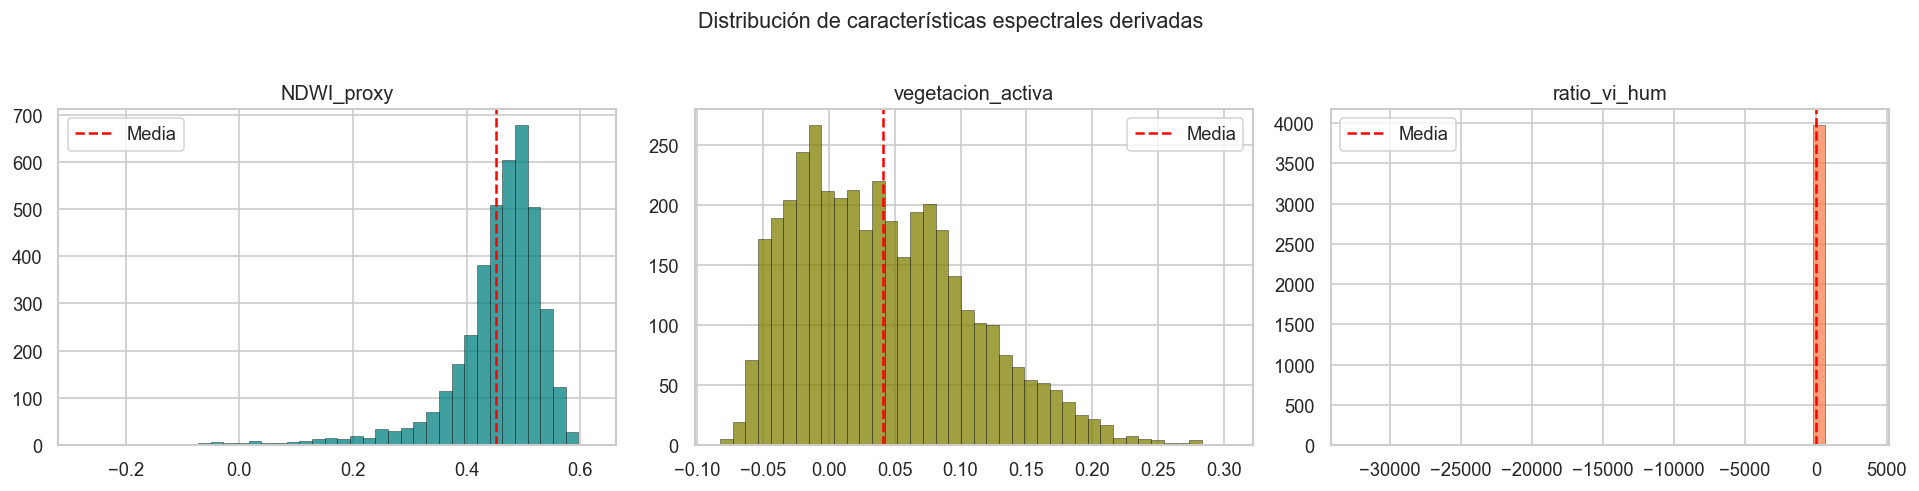

✓ Características espectrales derivadas creadas


In [21]:
fe = df_clean.copy()

# Divergencia vigor-humedad (proxy de estrés)
fe['NDWI_proxy'] = fe['NDVI'] - fe['NDMI']

# Condición vegetativa conjunta
fe['vegetacion_activa'] = fe['NDVI'] * fe['NDMI']

# Ratio vigor/humedad (evitar división por cero)
fe['ratio_vi_hum'] = fe['NDVI'] / (fe['NDMI'] + 1e-6)

print('Características espectrales derivadas:')
print(fe[['NDWI_proxy', 'vegetacion_activa', 'ratio_vi_hum']].describe().round(4))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col, color in zip(axes,
    ['NDWI_proxy', 'vegetacion_activa', 'ratio_vi_hum'],
    ['teal', 'olive', 'coral']):
    ax.hist(fe[col], bins=40, color=color, alpha=0.75, edgecolor='black', linewidth=0.3)
    ax.axvline(fe[col].mean(), color='red', linestyle='--', linewidth=1.5, label='Media')
    ax.set_title(col)
    ax.legend()
plt.suptitle('Distribución de características espectrales derivadas', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()
print('✓ Características espectrales derivadas creadas')

#### 2.1.2 Características Temporales (Ciclicidad)

**Justificación:**  
El mes y la estación son variables cíclicas: enero y diciembre están separados por 1 unidad real pero por 11 unidades numéricas. Usar el mes directamente introduce un sesgo de distancia artificial. La codificación **seno/coseno** preserva la continuidad del ciclo anual y es la técnica estándar para señales periódicas en ML (Géron, 2019).

Adicionalmente, se añade la **estación del año** como variable ordinal para capturar patrones agronómicos asociados a la temporada de lluvias/secas en Jalisco.

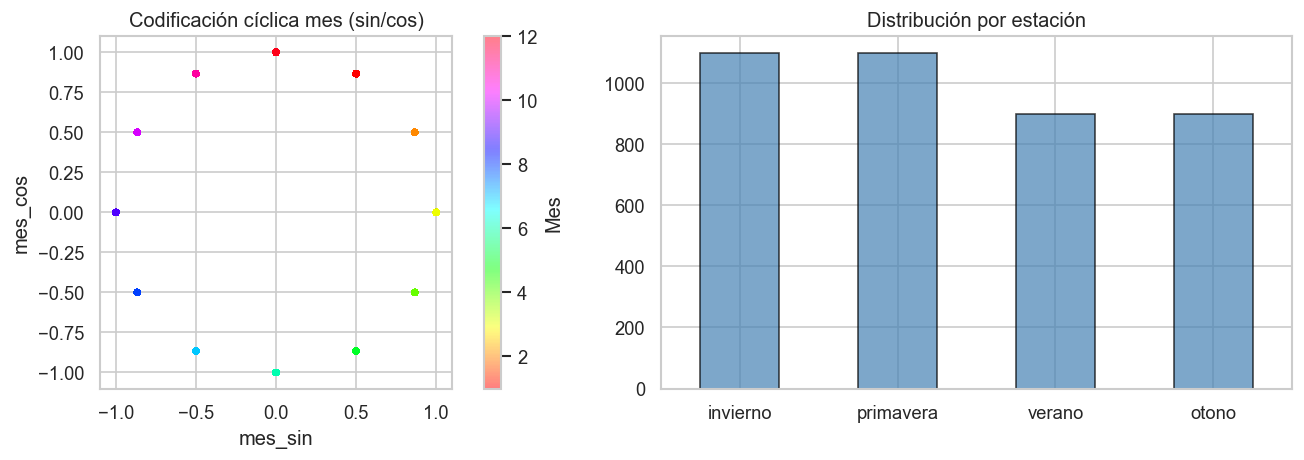

✓ Características temporales creadas


In [22]:
# Codificación cíclica del mes
fe['mes_sin'] = np.sin(2 * np.pi * fe['month'] / 12)
fe['mes_cos'] = np.cos(2 * np.pi * fe['month'] / 12)

# Estación del año (contexto Jalisco: temporada seca Nov-Apr, lluvias May-Oct)
def get_estacion(month):
    if month in [12, 1, 2]:
        return 'invierno'
    elif month in [3, 4, 5]:
        return 'primavera'
    elif month in [6, 7, 8]:
        return 'verano'
    else:
        return 'otono'

fe['estacion'] = fe['month'].apply(get_estacion)

# Indicador binario de temporada de lluvias
fe['temporada_lluvias'] = fe['month'].apply(lambda m: 1 if m in range(5, 11) else 0)

# Verificación visual de la codificación cíclica
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
scatter = axes[0].scatter(fe['mes_sin'], fe['mes_cos'],
                          c=fe['month'], cmap='hsv', s=10, alpha=0.5)
plt.colorbar(scatter, ax=axes[0], label='Mes')
axes[0].set_title('Codificación cíclica mes (sin/cos)')
axes[0].set_xlabel('mes_sin'); axes[0].set_ylabel('mes_cos')
axes[0].set_aspect('equal')

fe['estacion'].value_counts().plot(kind='bar', ax=axes[1], color='steelblue', alpha=0.7, edgecolor='black')
axes[1].set_title('Distribución por estación')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()
print('✓ Características temporales creadas')

#### 2.1.3 Características Estadísticas por Parcela (Lag / Rolling)

**Justificación:**  
El estrés hídrico es un fenómeno acumulativo. Las series temporales de NDVI/NDMI contienen memoria: el estado de la parcela en el mes *t* depende de meses anteriores. Se generan:  
- **Media móvil (3 meses)** de NDVI y NDMI: suaviza ruido y captura tendencias de corto plazo.  
- **Lag-1 y Lag-2**: valor del índice en el mes anterior y dos meses antes. Permite al modelo aprender la trayectoria reciente.  
- **Cambio mensual (delta)**: diferencia respecto al mes anterior. Detecta caídas bruscas como señal de estrés emergente.

Características de lag/rolling creadas:
       NDVI_roll3  NDVI_lag1  NDVI_delta  NDMI_roll3  NDMI_lag1  NDMI_delta
count   4000.0000  4000.0000   4000.0000   4000.0000  4000.0000   4000.0000
mean       0.5097     0.5095     -0.0015      0.0584     0.0589     -0.0013
std        0.1213     0.1368      0.1110      0.1079     0.1167      0.0688
min        0.1840     0.0404     -0.6456     -0.2537    -0.2626     -0.3391
25%        0.4191     0.4047     -0.0517     -0.0177    -0.0255     -0.0361
50%        0.5145     0.5134     -0.0186      0.0660     0.0632     -0.0084
75%        0.5984     0.6119      0.0204      0.1403     0.1449      0.0142
max        0.8468     0.8664      0.5646      0.3715     0.3765      0.3330


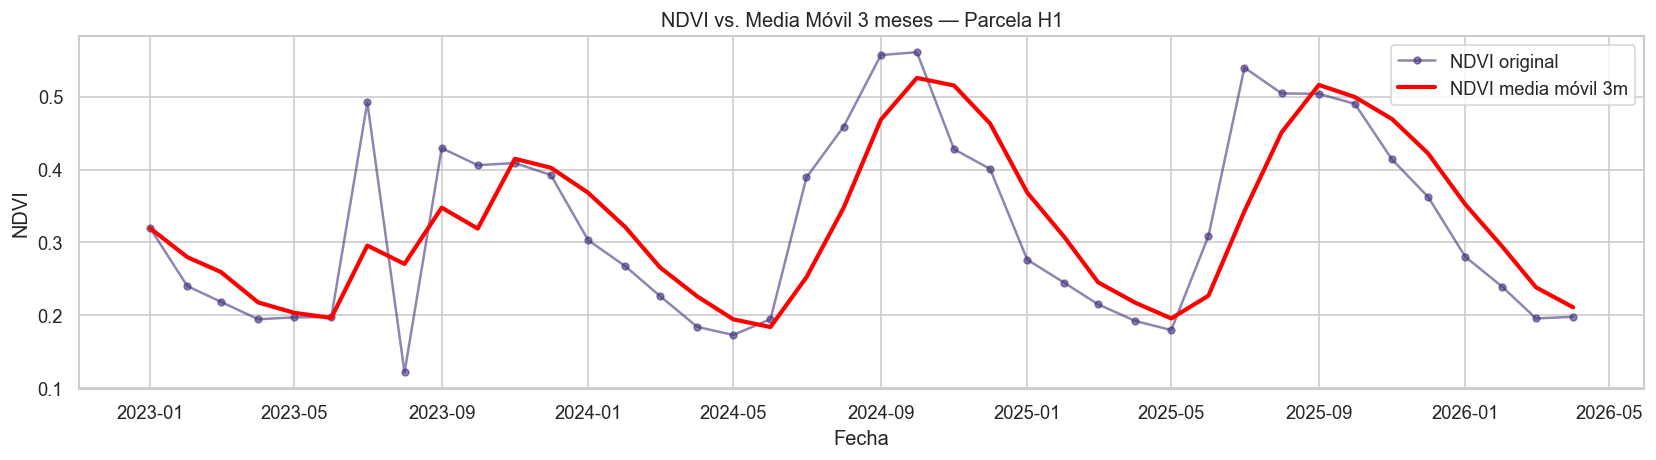

✓ Características de lag/rolling creadas


In [23]:
# Ordenar por parcela y fecha para que los lags sean correctos
fe = fe.sort_values(['name', 'date']).reset_index(drop=True)

for idx_col in ['NDVI', 'NDMI']:
    grp = fe.groupby('name')[idx_col]
    
    # Media móvil 3 meses
    fe[f'{idx_col}_roll3'] = grp.transform(lambda x: x.rolling(3, min_periods=1).mean())
    
    # Lags
    fe[f'{idx_col}_lag1'] = grp.shift(1)
    fe[f'{idx_col}_lag2'] = grp.shift(2)
    
    # Cambio mensual
    fe[f'{idx_col}_delta'] = grp.diff(1)

# Los NaN de los lags (primeras filas por parcela) se rellenan con la media
lag_cols = [c for c in fe.columns if 'lag' in c or 'delta' in c]
for col in lag_cols:
    fe[col] = fe[col].fillna(fe[col].mean())

print('Características de lag/rolling creadas:')
print(fe[['NDVI_roll3', 'NDVI_lag1', 'NDVI_delta',
          'NDMI_roll3', 'NDMI_lag1', 'NDMI_delta']].describe().round(4))

# Visualización: comparar NDVI vs NDVI_roll3 para una parcela
sample_parcela = 'H1'
mask = fe['name'] == sample_parcela
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(fe.loc[mask, 'date'], fe.loc[mask, 'NDVI'],
        label='NDVI original', alpha=0.6, marker='o', markersize=4)
ax.plot(fe.loc[mask, 'date'], fe.loc[mask, 'NDVI_roll3'],
        label='NDVI media móvil 3m', linewidth=2.5, color='red')
ax.set_title(f'NDVI vs. Media Móvil 3 meses — Parcela {sample_parcela}')
ax.set_xlabel('Fecha'); ax.set_ylabel('NDVI')
ax.legend()
plt.tight_layout()
plt.show()
print('✓ Características de lag/rolling creadas')

#### 2.1.4 Características Geoespaciales

**Justificación:**  
La altitud y la posición geográfica condicionan el microclima y las precipitaciones. Parcelas a mayor altitud suelen presentar menor temperatura y mayor humedad relativa. Se calcula la **distancia al centroide** del cluster de parcelas, que captura la posición relativa dentro del área de estudio y puede correlacionarse con gradientes espaciales de temperatura/humedad.

Características geoespaciales añadidas:
         lon_kml    lat_kml  altitud_m  dist_centroide
count  4000.0000  4000.0000     4000.0       4000.0000
mean   -103.4952    19.6235        0.0          0.0201
std       0.0170     0.0141        0.0          0.0094
min    -103.5269    19.6021        0.0          0.0032
25%    -103.5092    19.6127        0.0          0.0136
50%    -103.4935    19.6211        0.0          0.0199
75%    -103.4856    19.6339        0.0          0.0263
max    -103.4601    19.6632        0.0          0.0417


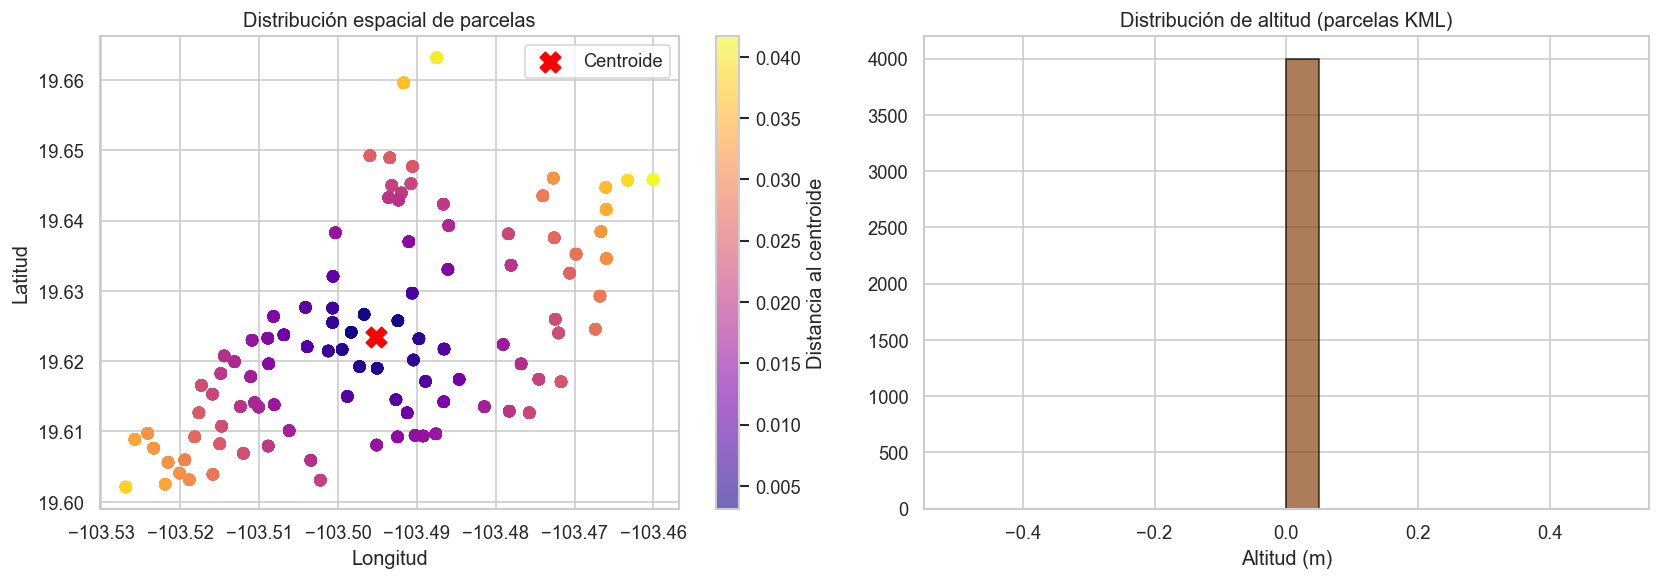

✓ Características geoespaciales añadidas


In [24]:
# Parsear KML para obtener coordenadas de las 100 parcelas
import xml.etree.ElementTree as ET

def parse_kml(path):
    tree = ET.parse(path)
    root = tree.getroot()
    ns = {'kml': 'http://www.opengis.net/kml/2.2'}
    records = []
    for pm in root.findall('.//kml:Placemark', ns):
        name = pm.find('kml:name', ns).text
        coords_raw = pm.find('.//kml:coordinates', ns).text.strip()
        lon, lat, alt = map(float, coords_raw.split(','))
        records.append({'name': name, 'lon_kml': lon, 'lat_kml': lat, 'altitud_m': alt})
    return pd.DataFrame(records)

gdf_kml = parse_kml(KML_PATH)

# Centroide del área
centroid_lon = gdf_kml['lon_kml'].mean()
centroid_lat = gdf_kml['lat_kml'].mean()

# Distancia euclidiana al centroide (en grados; suficiente para ranking relativo)
gdf_kml['dist_centroide'] = np.sqrt(
    (gdf_kml['lon_kml'] - centroid_lon)**2 +
    (gdf_kml['lat_kml'] - centroid_lat)**2
)

# Unir al dataset principal
fe = fe.merge(gdf_kml[['name', 'lon_kml', 'lat_kml', 'altitud_m', 'dist_centroide']],
              on='name', how='left')

print(f'Características geoespaciales añadidas:')
print(fe[['lon_kml', 'lat_kml', 'altitud_m', 'dist_centroide']].describe().round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
scatter = axes[0].scatter(fe['lon_kml'], fe['lat_kml'],
                           c=fe['dist_centroide'], cmap='plasma', s=40, alpha=0.6)
axes[0].scatter([centroid_lon], [centroid_lat], marker='X', color='red', s=150, zorder=5, label='Centroide')
plt.colorbar(scatter, ax=axes[0], label='Distancia al centroide')
axes[0].set_title('Distribución espacial de parcelas')
axes[0].set_xlabel('Longitud'); axes[0].set_ylabel('Latitud')
axes[0].legend()

axes[1].hist(fe['altitud_m'].unique() if len(fe['altitud_m'].unique()) > 1
             else fe['altitud_m'], bins=20, color='saddlebrown', alpha=0.7, edgecolor='black')
axes[1].set_title('Distribución de altitud (parcelas KML)')
axes[1].set_xlabel('Altitud (m)')
plt.tight_layout()
plt.show()
print('✓ Características geoespaciales añadidas')

### 2.2 Resumen de Características Generadas

In [25]:
nuevas_features = {
    'Espectral derivada': ['NDWI_proxy', 'vegetacion_activa', 'ratio_vi_hum'],
    'Temporal cíclica': ['mes_sin', 'mes_cos', 'temporada_lluvias'],
    'Categórica': ['estacion'],
    'Lag / Rolling NDVI': ['NDVI_roll3', 'NDVI_lag1', 'NDVI_lag2', 'NDVI_delta'],
    'Lag / Rolling NDMI': ['NDMI_roll3', 'NDMI_lag1', 'NDMI_lag2', 'NDMI_delta'],
    'Geoespacial': ['lon_kml', 'lat_kml', 'altitud_m', 'dist_centroide'],
}

print('=' * 55)
print(f'  RESUMEN DE FEATURES GENERADAS')
print('=' * 55)
total = 0
for grupo, cols in nuevas_features.items():
    print(f'  [{grupo}]')
    for c in cols:
        print(f'    • {c}')
    total += len(cols)
print('-' * 55)
print(f'  Total nuevas características: {total}')
print(f'  Total columnas en dataset FE: {fe.shape[1]}')
print('=' * 55)

  RESUMEN DE FEATURES GENERADAS
  [Espectral derivada]
    • NDWI_proxy
    • vegetacion_activa
    • ratio_vi_hum
  [Temporal cíclica]
    • mes_sin
    • mes_cos
    • temporada_lluvias
  [Categórica]
    • estacion
  [Lag / Rolling NDVI]
    • NDVI_roll3
    • NDVI_lag1
    • NDVI_lag2
    • NDVI_delta
  [Lag / Rolling NDMI]
    • NDMI_roll3
    • NDMI_lag1
    • NDMI_lag2
    • NDMI_delta
  [Geoespacial]
    • lon_kml
    • lat_kml
    • altitud_m
    • dist_centroide
-------------------------------------------------------
  Total nuevas características: 19
  Total columnas en dataset FE: 33


---
### 2.3 Incorporación de Características de Imagen (GeoTIFFs Sentinel‑2)


Cada observación parcela/mes se vincula con un patch GeoTIFF multibanda mediante `patch_path`. En lugar de convertir todos los píxeles RGB/NIR/SWIR en columnas —lo cual aumentaría demasiado la dimensionalidad— se extraen estadísticas compactas por banda:

- media,
- desviación estándar,
- mínimo,
- máximo,
- percentiles 25, 50 y 75,
- proporción de píxeles válidos.

Esto permite incorporar información espacial de las imágenes sin romper el enfoque tabular del notebook del equipo. Para modelos CNN, los GeoTIFFs pueden conservarse posteriormente como matrices multibanda, pero en este avance se agregan como **features tabulares resumidas**.

In [26]:
# ── Configuración para integrar imágenes GeoTIFF ──────────────
# Ajusta esta ruta si tu archivo está en otra carpeta.
from pathlib import Path
import re


LEVEL2_PATCH_DATASET_PATH = Path(r"C:\Users\omarh\Desktop\Maestria\avocado_project\data\processed\level2_patch_dataset_with_labels.csv")
RASTER_FEATURES_CACHE = Path(r"C:\Users\omarh\Desktop\Maestria\avocado_project\data\csv\raster_features_cache.csv")
    
# Bandas esperadas en cada patch:
# 1 B2, 2 B3, 3 B4, 4 B8, 5 B11, 6 NDVI, 7 NDMI
BAND_NAMES = ["B2", "B3", "B4", "B8", "B11", "NDVI_raster", "NDMI_raster"]

print("Level 2 patch dataset:", LEVEL2_PATCH_DATASET_PATH)
print("Raster cache:", RASTER_FEATURES_CACHE)

Level 2 patch dataset: C:\Users\omarh\Desktop\Maestria\avocado_project\data\processed\level2_patch_dataset_with_labels.csv
Raster cache: C:\Users\omarh\Desktop\Maestria\avocado_project\data\csv\raster_features_cache.csv


In [27]:
df_patches

,name,year_x,month_x,year_month,patch_path,lat,lon,year_y,month_y,date,image_count,NDVI,NDMI,year,month,patch_exists
0,H1,2023,1,2023-01,C:\Users\omarh\Desktop\Maestria\avocado_projec...,19.663164,-103.487470,2023.0,1.0,2023-01,4.0,0.319492,-0.063829,2023,1,True
1,H1,2023,2,2023-02,C:\Users\omarh\Desktop\Maestria\avocado_projec...,19.663164,-103.487470,2023.0,2.0,2023-02,6.0,0.240143,-0.107686,2023,2,True
2,H1,2023,3,2023-03,C:\Users\omarh\Desktop\Maestria\avocado_projec...,19.663164,-103.487470,2023.0,3.0,2023-03,6.0,0.218621,-0.139270,2023,3,True
3,H1,2023,4,2023-04,C:\Users\omarh\Desktop\Maestria\avocado_projec...,19.663164,-103.487470,2023.0,4.0,2023-04,6.0,0.194678,-0.141275,2023,4,True
4,H1,2023,5,2023-05,C:\Users\omarh\Desktop\Maestria\avocado_projec...,19.663164,-103.487470,2023.0,5.0,2023-05,6.0,0.197294,-0.153916,2023,5,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4095,H99,2026,1,2026-01,C:\Users\omarh\Desktop\Maestria\avocado_projec...,19.603889,-103.515854,2026.0,1.0,2026-01,5.0,0.525857,0.052167,2026,1,True
4096,H99,2026,2,2026-02,C:\Users\omarh\Desktop\Maestria\avocado_projec...,19.603889,-103.515854,2026.0,2.0,2026-02,5.0,0.481000,-0.011316,2026,2,True
4097,H99,2026,3,2026-03,C:\Users\omarh\Desktop\Maestria\avocado_projec...,19.603889,-103.515854,2026.0,3.0,2026-03,7.0,0.419845,-0.032500,2026,3,True
4098,H99,2026,4,2026-04,C:\Users\omarh\Desktop\Maestria\avocado_projec...,19.603889,-103.515854,2026.0,4.0,2026-04,7.0,0.403221,-0.033773,2026,4,True


In [28]:
# ── Cargar rutas a patches GeoTIFF y unirlas con el dataset tabular ──────────────
# La unión se realiza por name + year + month para no alterar el pipeline original.

raster_feature_cols = []
raster_features_available = False

if LEVEL2_PATCH_DATASET_PATH.exists():
    df_patches = pd.read_csv(LEVEL2_PATCH_DATASET_PATH)

    if 'year_month' not in df_patches.columns:
        df_patches['year_month'] = df_patches['year_x'].astype(str) + '-' + df_patches['month_x'].astype(str).str.zfill(2)

    df_patches['year'] = df_patches['year_x'].astype(int)
    df_patches['month'] = df_patches['month_x'].astype(int)
    df_patches['patch_path'] = df_patches['patch_path'].astype(str)
    df_patches['patch_exists'] = df_patches['patch_path'].apply(lambda p: Path(p).exists())

    patch_cols = ['name', 'year', 'month', 'patch_path', 'patch_exists']
    patch_cols = [c for c in patch_cols if c in df_patches.columns]

    fe = fe.merge(
        df_patches[patch_cols].drop_duplicates(subset=['name', 'year', 'month']),
        on=['name', 'year', 'month'],
        how='left'
    )

    print('✓ Dataset Level 2 cargado y unido con FE tabular')
    print('Shape fe después del merge:', fe.shape)
    print('Patches existentes:')
    display(fe['patch_exists'].value_counts(dropna=False))
else:
    print('⚠️ No se encontró level2_patch_dataset_with_labels.csv.')
    print('   El notebook continuará solo con features tabulares.')
    print('   Para activar features de imagen, coloca el archivo en:')
    print('  ', LEVEL2_PATCH_DATASET_PATH)

✓ Dataset Level 2 cargado y unido con FE tabular
Shape fe después del merge: (4000, 35)
Patches existentes:


patch_exists
True    4000
Name: count, dtype: int64

In [29]:
# ── Función para extraer estadísticas compactas desde cada GeoTIFF ──────────────

def extract_raster_features(patch_path):
    if rasterio is None:
        return {'raster_missing': 1}

    patch_path = Path(str(patch_path))

    if not patch_path.exists():
        return {'raster_missing': 1}

    features = {'raster_missing': 0}

    try:
        with rasterio.open(patch_path) as src:
            stack = src.read().astype('float32')
    except Exception as e:
        return {'raster_missing': 1, 'raster_error': str(e)}

    for i, band_name in enumerate(BAND_NAMES):
        if i >= stack.shape[0]:
            continue

        arr = stack[i]
        valid = np.isfinite(arr)
        features[f'{band_name}_valid_ratio'] = float(valid.mean())

        if valid.sum() == 0:
            for stat in ['mean', 'std', 'min', 'max', 'p25', 'p50', 'p75']:
                features[f'{band_name}_{stat}'] = np.nan
            continue

        vals = arr[valid]
        features[f'{band_name}_mean'] = float(np.nanmean(vals))
        features[f'{band_name}_std'] = float(np.nanstd(vals))
        features[f'{band_name}_min'] = float(np.nanmin(vals))
        features[f'{band_name}_max'] = float(np.nanmax(vals))
        features[f'{band_name}_p25'] = float(np.nanpercentile(vals, 25))
        features[f'{band_name}_p50'] = float(np.nanpercentile(vals, 50))
        features[f'{band_name}_p75'] = float(np.nanpercentile(vals, 75))

    return features

# Prueba rápida con un patch disponible
if 'patch_exists' in fe.columns and fe['patch_exists'].fillna(False).any():
    sample_patch = fe.loc[fe['patch_exists'].fillna(False), 'patch_path'].iloc[0]
    print('Patch de prueba:', sample_patch)
    sample_features = extract_raster_features(sample_patch)
    display(pd.DataFrame([sample_features]).T.head(20))
else:
    print('No hay patches disponibles para probar extracción raster.')

Patch de prueba: C:\Users\omarh\Desktop\Maestria\avocado_project\data\processed\level2_individual_patches\H1\H1_2023_01_stack.tif


,0
raster_missing,0.000000
B2_valid_ratio,0.760349
B2_mean,0.081061
B2_std,0.081382
B2_min,0.016750
B2_max,0.483800
B2_p25,0.038650
B2_p50,0.049225
B2_p75,0.076100
B3_valid_ratio,0.760349


In [30]:
# ── Extraer features raster para todo el dataset ──────────────
# Se usa caché para no recalcular si ya se ejecutó previamente.

if 'patch_path' in fe.columns and fe['patch_path'].notna().any() and rasterio is not None:
    RASTER_FEATURES_CACHE.parent.mkdir(parents=True, exist_ok=True)

    if RASTER_FEATURES_CACHE.exists():
        print('✓ Cargando raster features desde caché:', RASTER_FEATURES_CACHE)
        raster_features_df = pd.read_csv(RASTER_FEATURES_CACHE)
    else:
        print('Extrayendo raster features desde GeoTIFFs...')
        feature_rows = []

        for idx, row in fe.iterrows():
            raster_feats = extract_raster_features(row.get('patch_path'))
            raster_feats['row_index'] = idx
            feature_rows.append(raster_feats)

        raster_features_df = pd.DataFrame(feature_rows)
        raster_features_df.to_csv(RASTER_FEATURES_CACHE, index=False)
        print('✓ Caché guardado en:', RASTER_FEATURES_CACHE)

    raster_feature_cols = [
        c for c in raster_features_df.columns
        if c not in ['row_index', 'raster_error']
    ]

    fe = pd.concat(
        [
            fe.reset_index(drop=True),
            raster_features_df.drop(columns=['row_index', 'raster_error'], errors='ignore').reset_index(drop=True)
        ],
        axis=1
    )

    raster_features_available = True

    print('✓ Features raster agregadas al dataset FE')
    print('Número de raster features:', len(raster_feature_cols))
    print('Shape final fe:', fe.shape)
    display(fe[raster_feature_cols].head())
else:
    raster_feature_cols = []
    raster_features_available = False
    print('⚠️ No se agregaron raster features. Se continuará con el FE tabular original.')

✓ Cargando raster features desde caché: C:\Users\omarh\Desktop\Maestria\avocado_project\data\csv\raster_features_cache.csv
✓ Features raster agregadas al dataset FE
Número de raster features: 57
Shape final fe: (4000, 92)


,raster_missing,B2_valid_ratio,B2_mean,B2_std,B2_min,B2_max,B2_p25,B2_p50,B2_p75,B3_valid_ratio,...,NDVI_raster_p50,NDVI_raster_p75,NDMI_raster_valid_ratio,NDMI_raster_mean,NDMI_raster_std,NDMI_raster_min,NDMI_raster_max,NDMI_raster_p25,NDMI_raster_p50,NDMI_raster_p75
0,0,0.760349,0.081061,0.081382,0.01675,0.4838,0.038650,0.049225,0.076100,0.760349,...,0.351475,0.407455,0.760349,-0.062503,0.109622,-0.370665,0.330428,-0.154393,-0.078310,0.021646
1,0,0.760349,0.087506,0.074088,0.01960,0.4578,0.048450,0.058000,0.083850,0.760349,...,0.252339,0.294343,0.760349,-0.107314,0.109093,-0.358308,0.230633,-0.200483,-0.121469,-0.036195
2,0,0.760349,0.089525,0.069007,0.02540,0.4556,0.054600,0.062325,0.087675,0.760349,...,0.229503,0.261698,0.760349,-0.137835,0.115500,-0.346518,0.227178,-0.231254,-0.156749,-0.077210
3,0,0.760349,0.099554,0.074065,0.02585,0.4760,0.060612,0.068600,0.098788,0.760349,...,0.208552,0.234425,0.760349,-0.141721,0.106217,-0.332760,0.221934,-0.226567,-0.160626,-0.087903
4,0,0.760349,0.100179,0.074876,0.02875,0.5016,0.061762,0.070400,0.100850,0.760349,...,0.203178,0.236465,0.760349,-0.152567,0.106140,-0.322883,0.256815,-0.240002,-0.172914,-0.094470


**Justificación de la integración de imágenes:**  
Estas variables raster incorporan información espacial de los patches Sentinel‑2 sin aumentar excesivamente la dimensionalidad. En vez de transformar miles de píxeles en columnas, se resumen las bandas e índices en estadísticas por patch. Esto permite que los métodos posteriores de selección de características, PCA y Factor Analysis evalúen también la contribución de la información visual.

---
## 3. Codificación de Variables Categóricas

### 3.1 Codificación de `estacion` (One-Hot Encoding)

**Justificación:**  
La variable `estacion` tiene 4 categorías sin orden intrínseco (no es ordinal en sentido estricto para modelos de ML). Se aplica **One-Hot Encoding (OHE)** para evitar que el modelo asuma una relación de magnitud entre categorías. Se elimina una columna (*drop='first'*) para evitar multicolinealidad perfecta (dummy trap).

In [31]:
fe = pd.get_dummies(fe, columns=['estacion'], drop_first=True, dtype=int)

estacion_cols = [c for c in fe.columns if c.startswith('estacion_')]
print(f'Columnas OHE generadas: {estacion_cols}')
print(fe[estacion_cols].value_counts().head())

print('\n✓ One-Hot Encoding aplicado a estacion (drop_first=True para evitar dummy trap)')

Columnas OHE generadas: ['estacion_otono', 'estacion_primavera', 'estacion_verano']
estacion_otono  estacion_primavera  estacion_verano
0               0                   0                  1100
                1                   0                  1100
                0                   1                   900
1               0                   0                   900
Name: count, dtype: int64

✓ One-Hot Encoding aplicado a estacion (drop_first=True para evitar dummy trap)


### 3.2 Codificación de `stress_class` (Label Encoding Ordinal)

**Justificación:**  
La variable objetivo `stress_class` tiene un orden natural implícito:  
*no_relative_stress* < *moderate_possible_stress* < *severe_possible_stress*  

Se aplica **Label Encoding ordinal** explícito para modelado de clasificación, preservando el ordenamiento semántico. También se mantiene la versión de texto para interpretabilidad.

Distribución de clases codificadas:
stress_class              stress_label
moderate_possible_stress  1                600
no_relative_stress        0               3000
severe_possible_stress    2                400
Name: count, dtype: int64


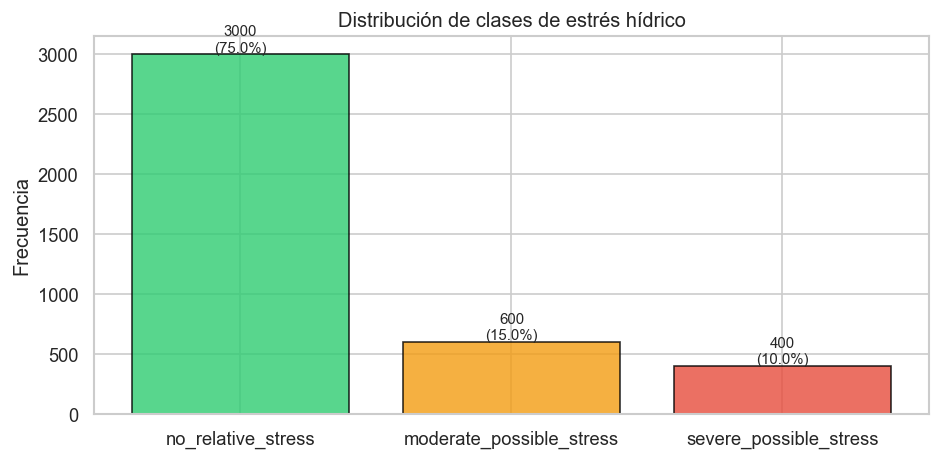

✓ Codificación ordinal de variable objetivo aplicada


In [32]:
stress_map = {
    'no_relative_stress': 0,
    'moderate_possible_stress': 1,
    'severe_possible_stress': 2
}
fe['stress_label'] = fe['stress_class'].map(stress_map)

print('Distribución de clases codificadas:')
print(fe[['stress_class', 'stress_label']].value_counts().sort_index())

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#2ecc71', '#f39c12', '#e74c3c']
counts = fe['stress_class'].value_counts()[list(stress_map.keys())]
ax.bar(counts.index, counts.values, color=colors, edgecolor='black', alpha=0.8)
ax.set_title('Distribución de clases de estrés hídrico')
ax.set_ylabel('Frecuencia')
for i, (k, v) in enumerate(counts.items()):
    ax.text(i, v + 20, f'{v}\n({v/len(fe)*100:.1f}%)', ha='center', fontsize=9)
plt.tight_layout()
plt.show()
print('✓ Codificación ordinal de variable objetivo aplicada')

---
## 4. Escalamiento y Transformación de Variables

### 4.1 Test de Normalidad Pre-Transformación

Se evalúa la distribución de las variables numéricas mediante **sesgo (skewness)** y **curtosis** para decidir qué transformaciones son necesarias.

In [33]:
num_cols_fe = [
    'NDVI', 'NDMI', 'NDWI_proxy', 'vegetacion_activa', 'ratio_vi_hum',
    'NDVI_roll3', 'NDVI_delta', 'NDMI_roll3', 'NDMI_delta',
    'dist_centroide', 'image_count'
]

# Agregar features raster si existen.
# Esto permite que el análisis de normalidad también revise variables derivadas de imagen.
num_cols_fe = [c for c in num_cols_fe if c in fe.columns] + [
    c for c in raster_feature_cols
    if c in fe.columns and pd.api.types.is_numeric_dtype(fe[c])
]

normalidad = []
for col in num_cols_fe:
    s = skew(fe[col].dropna())
    k = kurtosis(fe[col].dropna())
    sample = fe[col].dropna().sample(min(5000, len(fe[col].dropna())), random_state=42)
    stat, p = shapiro(sample)
    normalidad.append({'Feature': col, 'Sesgo': round(s, 4),
                        'Curtosis': round(k, 4), 'Shapiro p': round(p, 6),
                        'Normal (p>0.05)': 'Sí' if p > 0.05 else 'No'})

norm_df = pd.DataFrame(normalidad)
print('=== TEST DE NORMALIDAD PRE-TRANSFORMACIÓN ===')
display(norm_df.set_index('Feature'))

=== TEST DE NORMALIDAD PRE-TRANSFORMACIÓN ===


,Sesgo,Curtosis,Shapiro p,Normal (p>0.05)
Feature,,,,
NDVI,-0.1558,-0.5986,0.0,No
NDMI,-0.1629,-0.5894,0.0,No
NDWI_proxy,-2.6003,10.2615,0.0,No
vegetacion_activa,0.6232,-0.0635,0.0,No
ratio_vi_hum,-59.1969,3656.4204,0.0,No
...,...,...,...,...
NDMI_raster_min,0.2012,-0.1490,0.0,No
NDMI_raster_max,-0.8876,0.7170,0.0,No
NDMI_raster_p25,0.1097,-0.5899,0.0,No


### 4.2 Transformaciones para Reducir Sesgo

**Justificación de las transformaciones:**

| Variable | Problema | Transformación | Razón |
|---|---|---|---|
| `ratio_vi_hum` | Sesgo positivo alto (cola derecha) | Logarítmica | Comprime valores extremos sin perder información |
| `vegetacion_activa` | Valores negativos posibles, sesgo | Yeo-Johnson | Maneja negativos; más flexible que Box-Cox |
| `NDVI_delta`, `NDMI_delta` | Distribución bimodal/sesgada | Yeo-Johnson | Adecuada para deltas con valores positivos y negativos |
| `dist_centroide` | Sesgo moderado | Raíz cuadrada | Transformación suave para sesgos moderados |

Se aplica **Yeo-Johnson** sobre variables que pueden contener ceros o negativos, y **log(x+ε)** sobre `ratio_vi_hum` donde todos los valores son positivos.

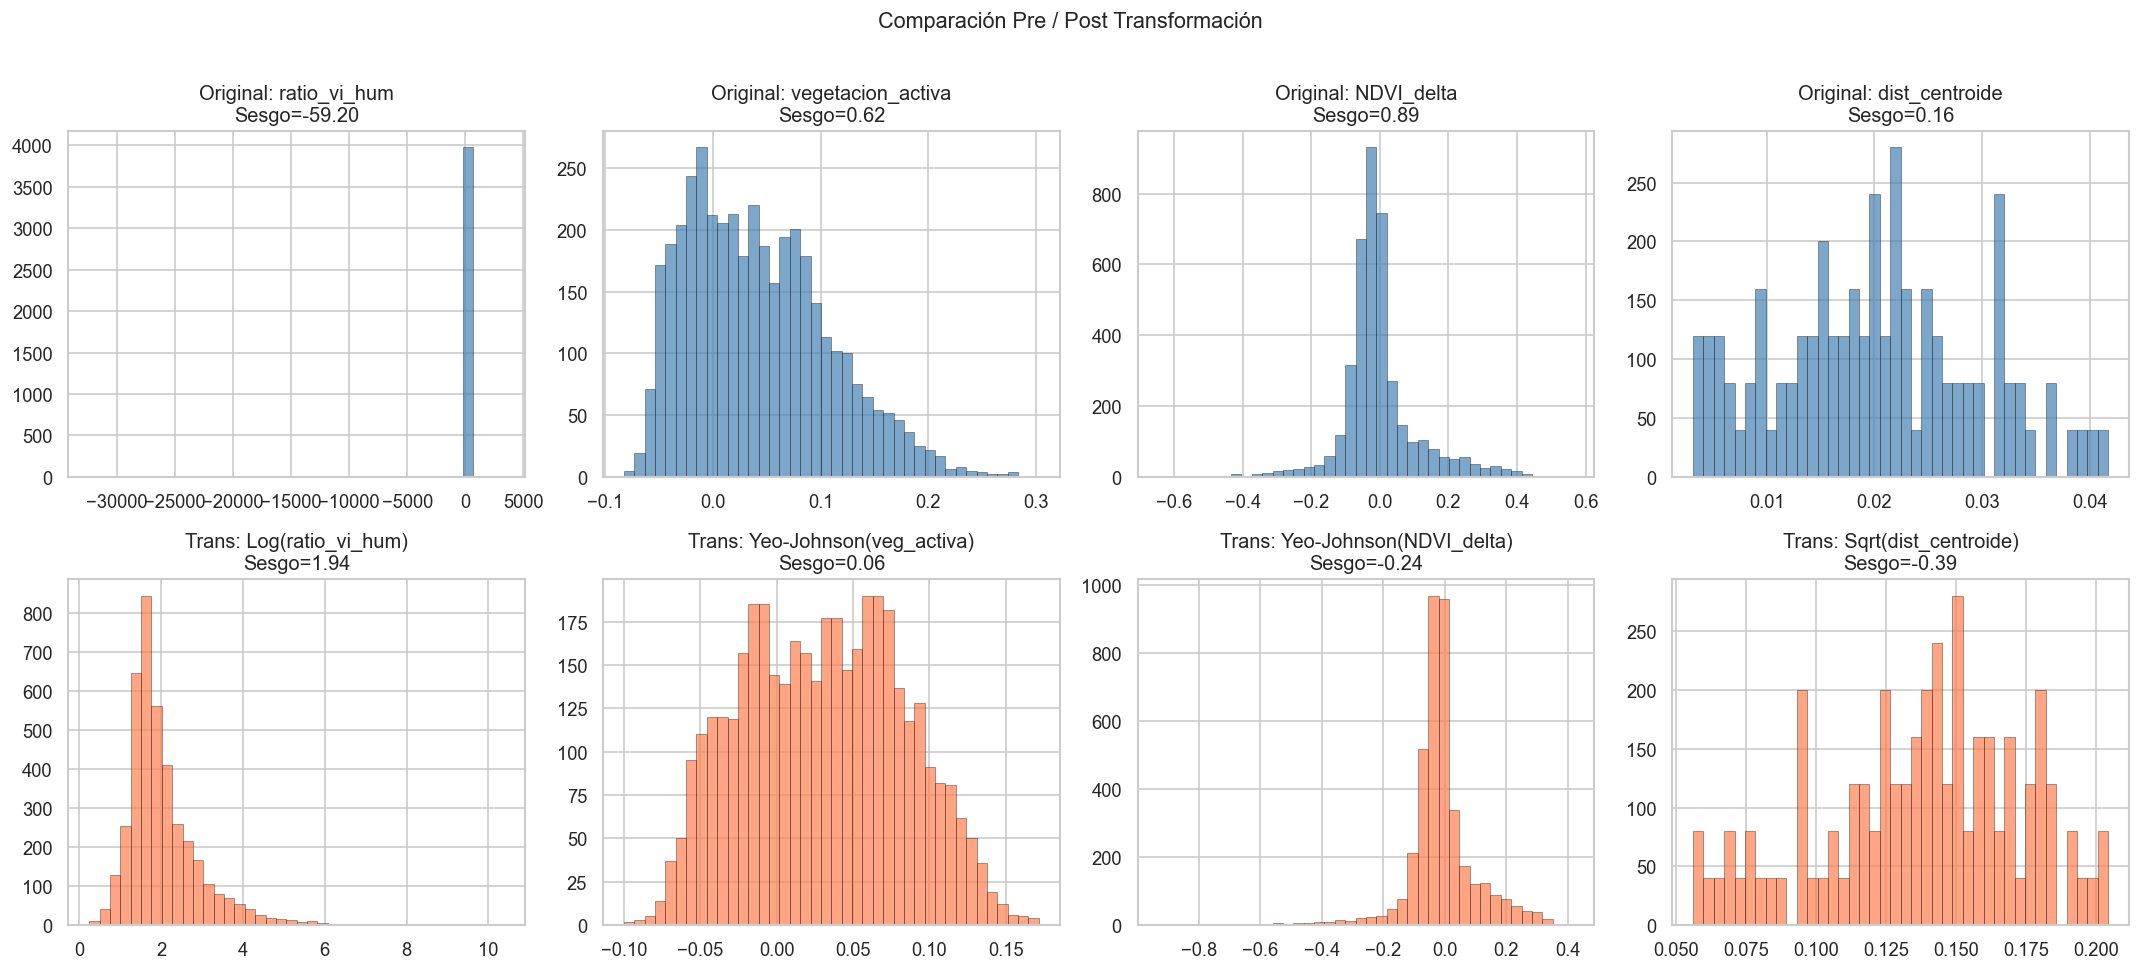

✓ Transformaciones aplicadas


In [34]:
fe_t = fe.copy()

# 1. Log transform: ratio_vi_hum (valores >> 0)
fe_t['ratio_vi_hum_log'] = np.log1p(np.abs(fe_t['ratio_vi_hum']))

# 2. Raíz cuadrada: dist_centroide
fe_t['dist_centroide_sqrt'] = np.sqrt(fe_t['dist_centroide'])

# 3. Yeo-Johnson: deltas y vegetacion_activa
pt = PowerTransformer(method='yeo-johnson', standardize=False)
yj_cols = ['NDVI_delta', 'NDMI_delta', 'vegetacion_activa']
fe_t[['NDVI_delta_yj', 'NDMI_delta_yj', 'vegetacion_activa_yj']] = \
    pt.fit_transform(fe_t[yj_cols])

# Comparación visual pre/post
compare_pairs = [
    ('ratio_vi_hum', 'ratio_vi_hum_log', 'Log(ratio_vi_hum)'),
    ('vegetacion_activa', 'vegetacion_activa_yj', 'Yeo-Johnson(veg_activa)'),
    ('NDVI_delta', 'NDVI_delta_yj', 'Yeo-Johnson(NDVI_delta)'),
    ('dist_centroide', 'dist_centroide_sqrt', 'Sqrt(dist_centroide)')
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for i, (orig, trans, trans_label) in enumerate(compare_pairs):
    ax_orig = axes[0, i]
    ax_trans = axes[1, i]
    ax_orig.hist(fe_t[orig], bins=40, color='steelblue', alpha=0.7, edgecolor='black', lw=0.3)
    ax_orig.set_title(f'Original: {orig}\nSesgo={skew(fe_t[orig]):.2f}')
    ax_trans.hist(fe_t[trans], bins=40, color='coral', alpha=0.7, edgecolor='black', lw=0.3)
    ax_trans.set_title(f'Trans: {trans_label}\nSesgo={skew(fe_t[trans]):.2f}')

plt.suptitle('Comparación Pre / Post Transformación', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()
print('✓ Transformaciones aplicadas')

### 4.3 Escalamiento Final del Dataset

**Justificación de la elección de escalador:**

Se aplica **Estandarización Z-score** (`StandardScaler`) como técnica principal porque:
1. La mayoría de variables post-transformación se aproximan a distribución normal.
2. Los algoritmos de gradient descent (SVM, Logistic Regression, redes neuronales) y los basados en distancias (KNN, K-Means) convergen más rápido cuando las variables tienen media 0 y desviación estándar 1.
3. Maneja mejor los outliers moderados que Min-Max, que es sensible a valores extremos.

Se conserva también una versión **Min-Max [0,1]** para algoritmos que requieren rangos acotados (árboles de decisión no lo requieren, pero SVM con kernel RBF sí).

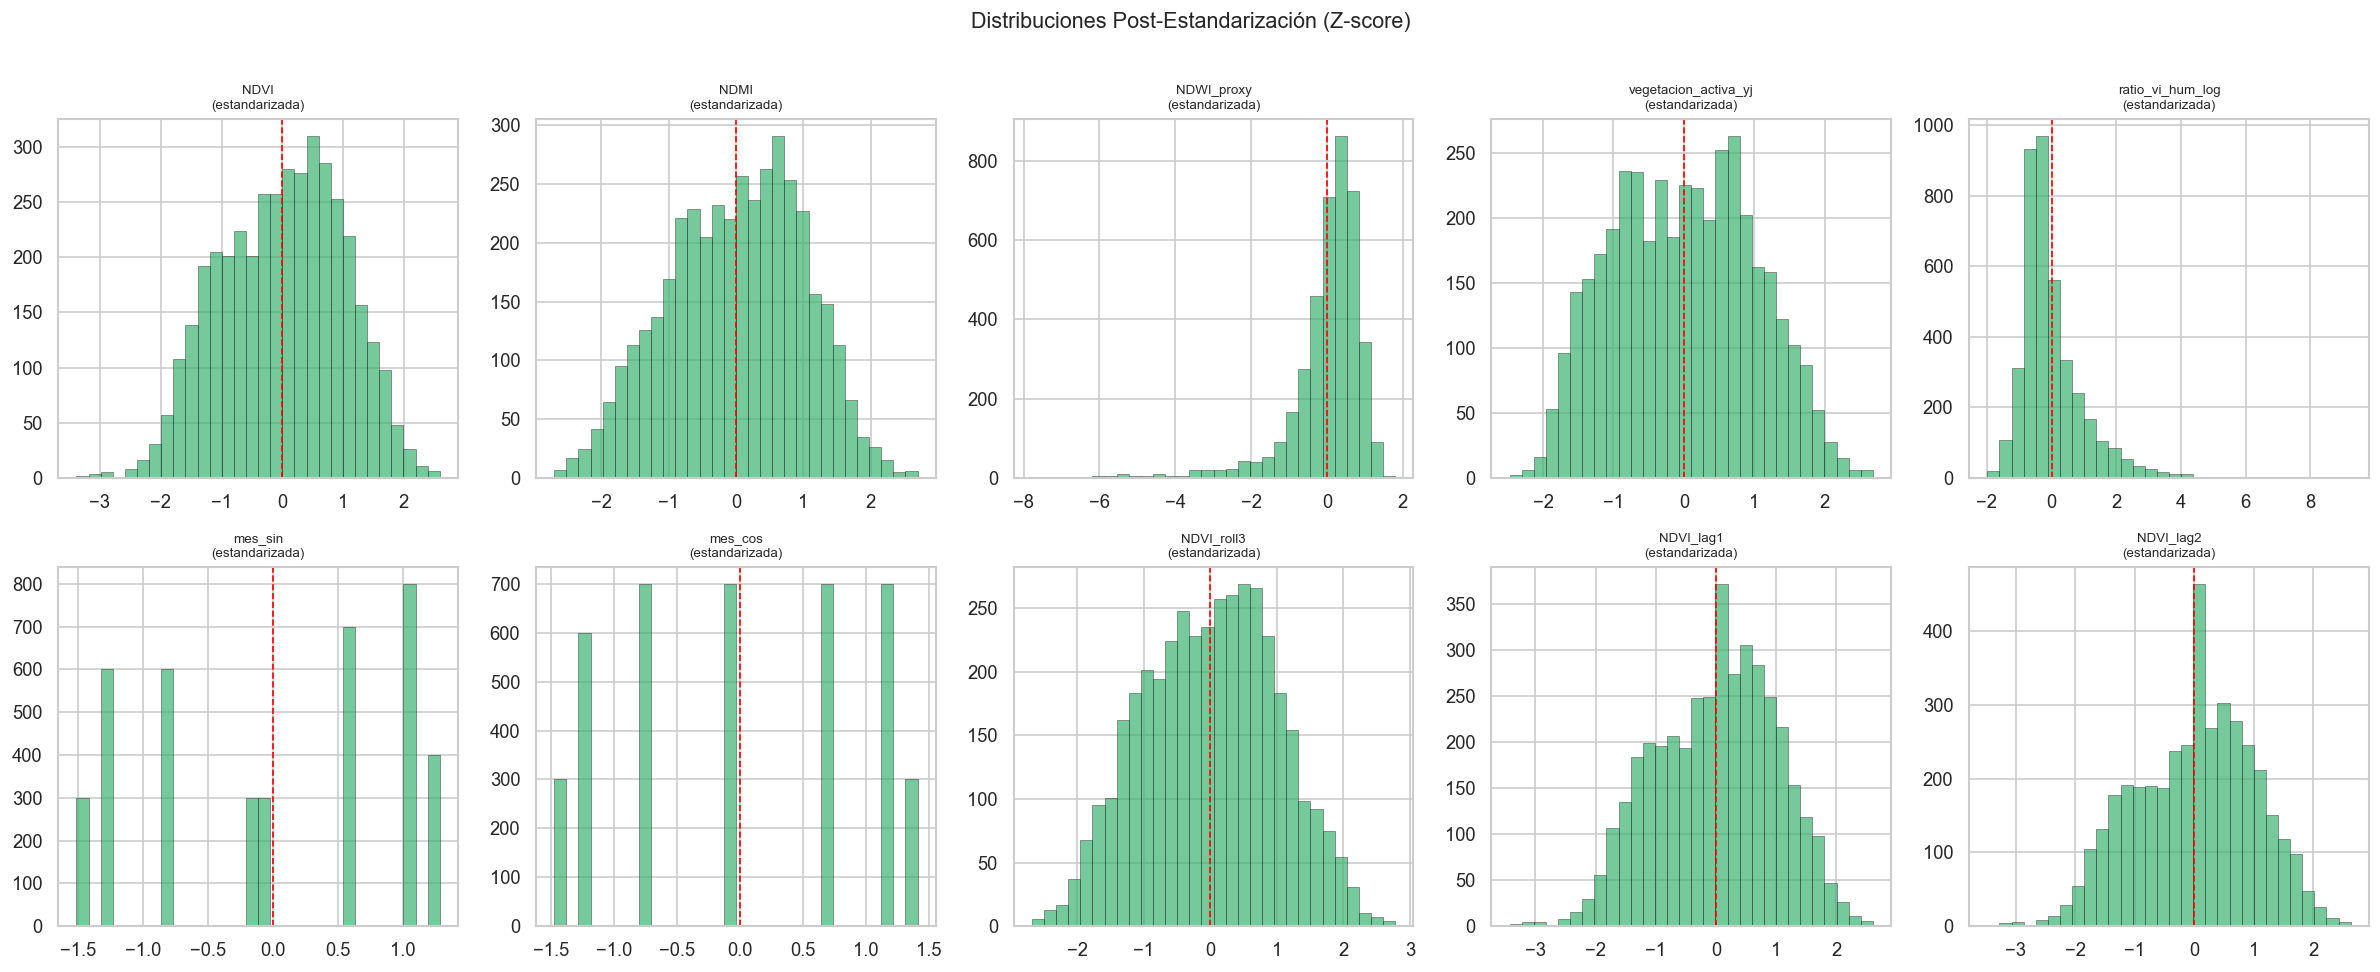

✓ Escalamiento completado: 76 features escaladas (Z-score + Min-Max)


In [35]:
# Definir el conjunto final de features numéricas para escalar
features_num_final = [
    'NDVI', 'NDMI',
    'NDWI_proxy', 'vegetacion_activa_yj',
    'ratio_vi_hum_log',
    'mes_sin', 'mes_cos',
    'NDVI_roll3', 'NDVI_lag1', 'NDVI_lag2', 'NDVI_delta_yj',
    'NDMI_roll3', 'NDMI_lag1', 'NDMI_lag2', 'NDMI_delta_yj',
    'lon_kml', 'lat_kml', 'dist_centroide_sqrt',
    'image_count'
]

# Agregar features raster compactas si fueron extraídas correctamente.
features_num_final = [c for c in features_num_final if c in fe_t.columns] + [
    c for c in raster_feature_cols
    if c in fe_t.columns and pd.api.types.is_numeric_dtype(fe_t[c])
]

scaler_final = StandardScaler()
scaled_cols = [f'{c}_sc' for c in features_num_final]
fe_t[scaled_cols] = scaler_final.fit_transform(fe_t[features_num_final])

scaler_mm2 = MinMaxScaler()
mm_cols = [f'{c}_mm' for c in features_num_final]
fe_t[mm_cols] = scaler_mm2.fit_transform(fe_t[features_num_final])

# Visualización de distribuciones post-escala
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
sample_feats = features_num_final[:10]
for i, col in enumerate(sample_feats):
    ax = axes[i // 5, i % 5]
    ax.hist(fe_t[f'{col}_sc'], bins=30, color='mediumseagreen', alpha=0.7, edgecolor='black', lw=0.3)
    ax.set_title(f'{col}\n(estandarizada)', fontsize=8)
    ax.axvline(0, color='red', linestyle='--', linewidth=1)
plt.suptitle('Distribuciones Post-Estandarización (Z-score)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(f'✓ Escalamiento completado: {len(features_num_final)} features escaladas (Z-score + Min-Max)')

---
## 5. Selección de Características (Feature Selection)

### 5.1 Umbral de Varianza

**Justificación:**  
Variables con varianza cercana a cero aportan muy poca información discriminativa (son casi constantes). El umbral de varianza es un filtro rápido y no supervisado que elimina estas variables antes de métodos más costosos. Se usa como primer paso de limpieza.

Umbral de varianza (threshold=0.01):
  Características retenidas: 28
  Características eliminadas: 48
  Eliminadas: ['NDWI_proxy', 'vegetacion_activa_yj', 'NDMI_delta_yj', 'lon_kml', 'lat_kml', 'dist_centroide_sqrt', 'raster_missing', 'B2_valid_ratio', 'B2_mean', 'B2_std', 'B2_min', 'B2_p25', 'B2_p50', 'B2_p75', 'B3_valid_ratio', 'B3_mean', 'B3_std', 'B3_min', 'B3_p25', 'B3_p50', 'B3_p75', 'B4_valid_ratio', 'B4_mean', 'B4_std', 'B4_min', 'B4_p25', 'B4_p50', 'B4_p75', 'B8_valid_ratio', 'B8_mean', 'B8_std', 'B8_min', 'B8_max', 'B8_p25', 'B8_p50', 'B8_p75', 'B11_valid_ratio', 'B11_mean', 'B11_std', 'B11_min', 'B11_max', 'B11_p25', 'B11_p50', 'B11_p75', 'NDVI_raster_valid_ratio', 'NDVI_raster_std', 'NDMI_raster_valid_ratio', 'NDMI_raster_std']


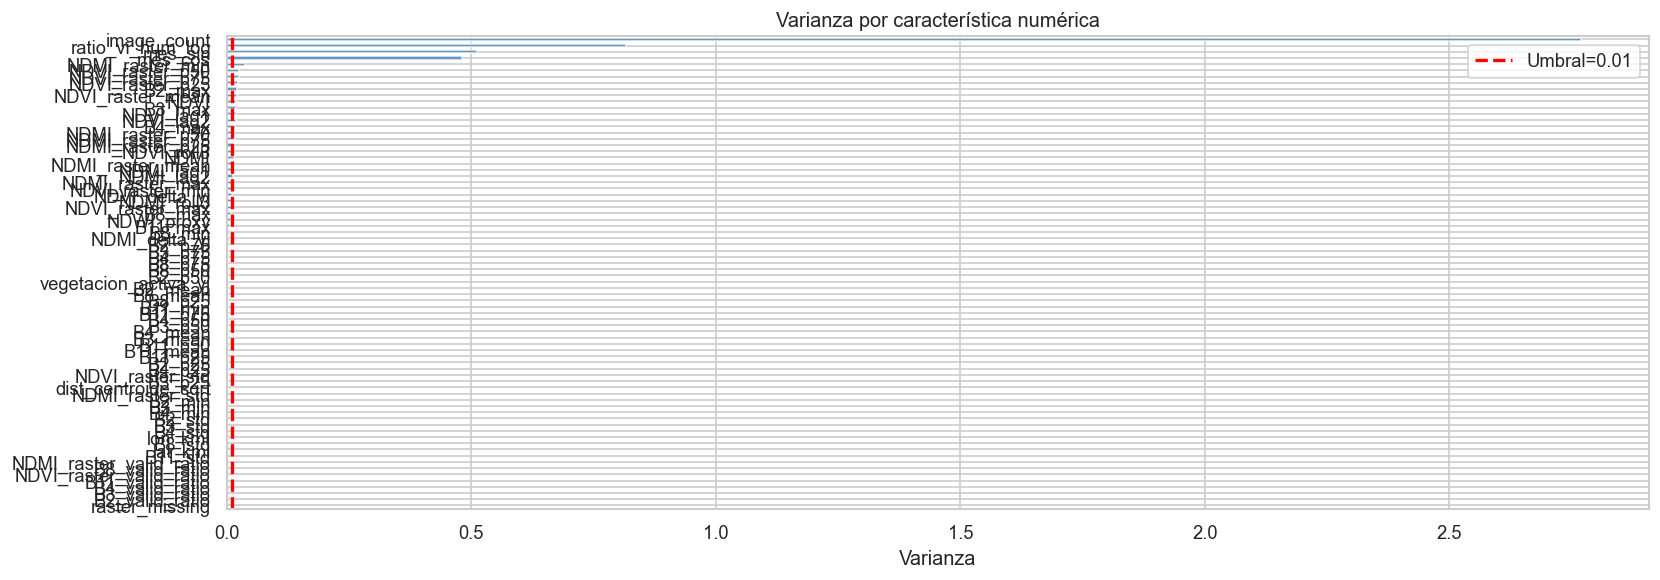

In [36]:
X_var = fe_t[features_num_final].copy()

selector_var = VarianceThreshold(threshold=0.01)
selector_var.fit(X_var)

variances = pd.Series(selector_var.variances_, index=X_var.columns)
cols_retained = X_var.columns[selector_var.get_support()].tolist()
cols_removed = X_var.columns[~selector_var.get_support()].tolist()

print(f'Umbral de varianza (threshold=0.01):')
print(f'  Características retenidas: {len(cols_retained)}')
print(f'  Características eliminadas: {len(cols_removed)}')
if cols_removed:
    print(f'  Eliminadas: {cols_removed}')

fig, ax = plt.subplots(figsize=(14, 5))
variances.sort_values().plot(kind='barh', ax=ax, color='steelblue', alpha=0.75)
ax.axvline(0.01, color='red', linestyle='--', linewidth=2, label='Umbral=0.01')
ax.set_title('Varianza por característica numérica')
ax.set_xlabel('Varianza')
ax.legend()
plt.tight_layout()
plt.show()

### 5.2 Análisis de Correlación

**Justificación:**  
Pares de variables altamente correlacionadas (|r| > 0.90) introducen multicolinealidad, que:
- Infla la varianza de los coeficientes en modelos lineales.
- Duplica información sin agregar poder predictivo.

Se elimina una variable de cada par altamente correlacionado, priorizando conservar la más interpretable en el dominio agronómico.

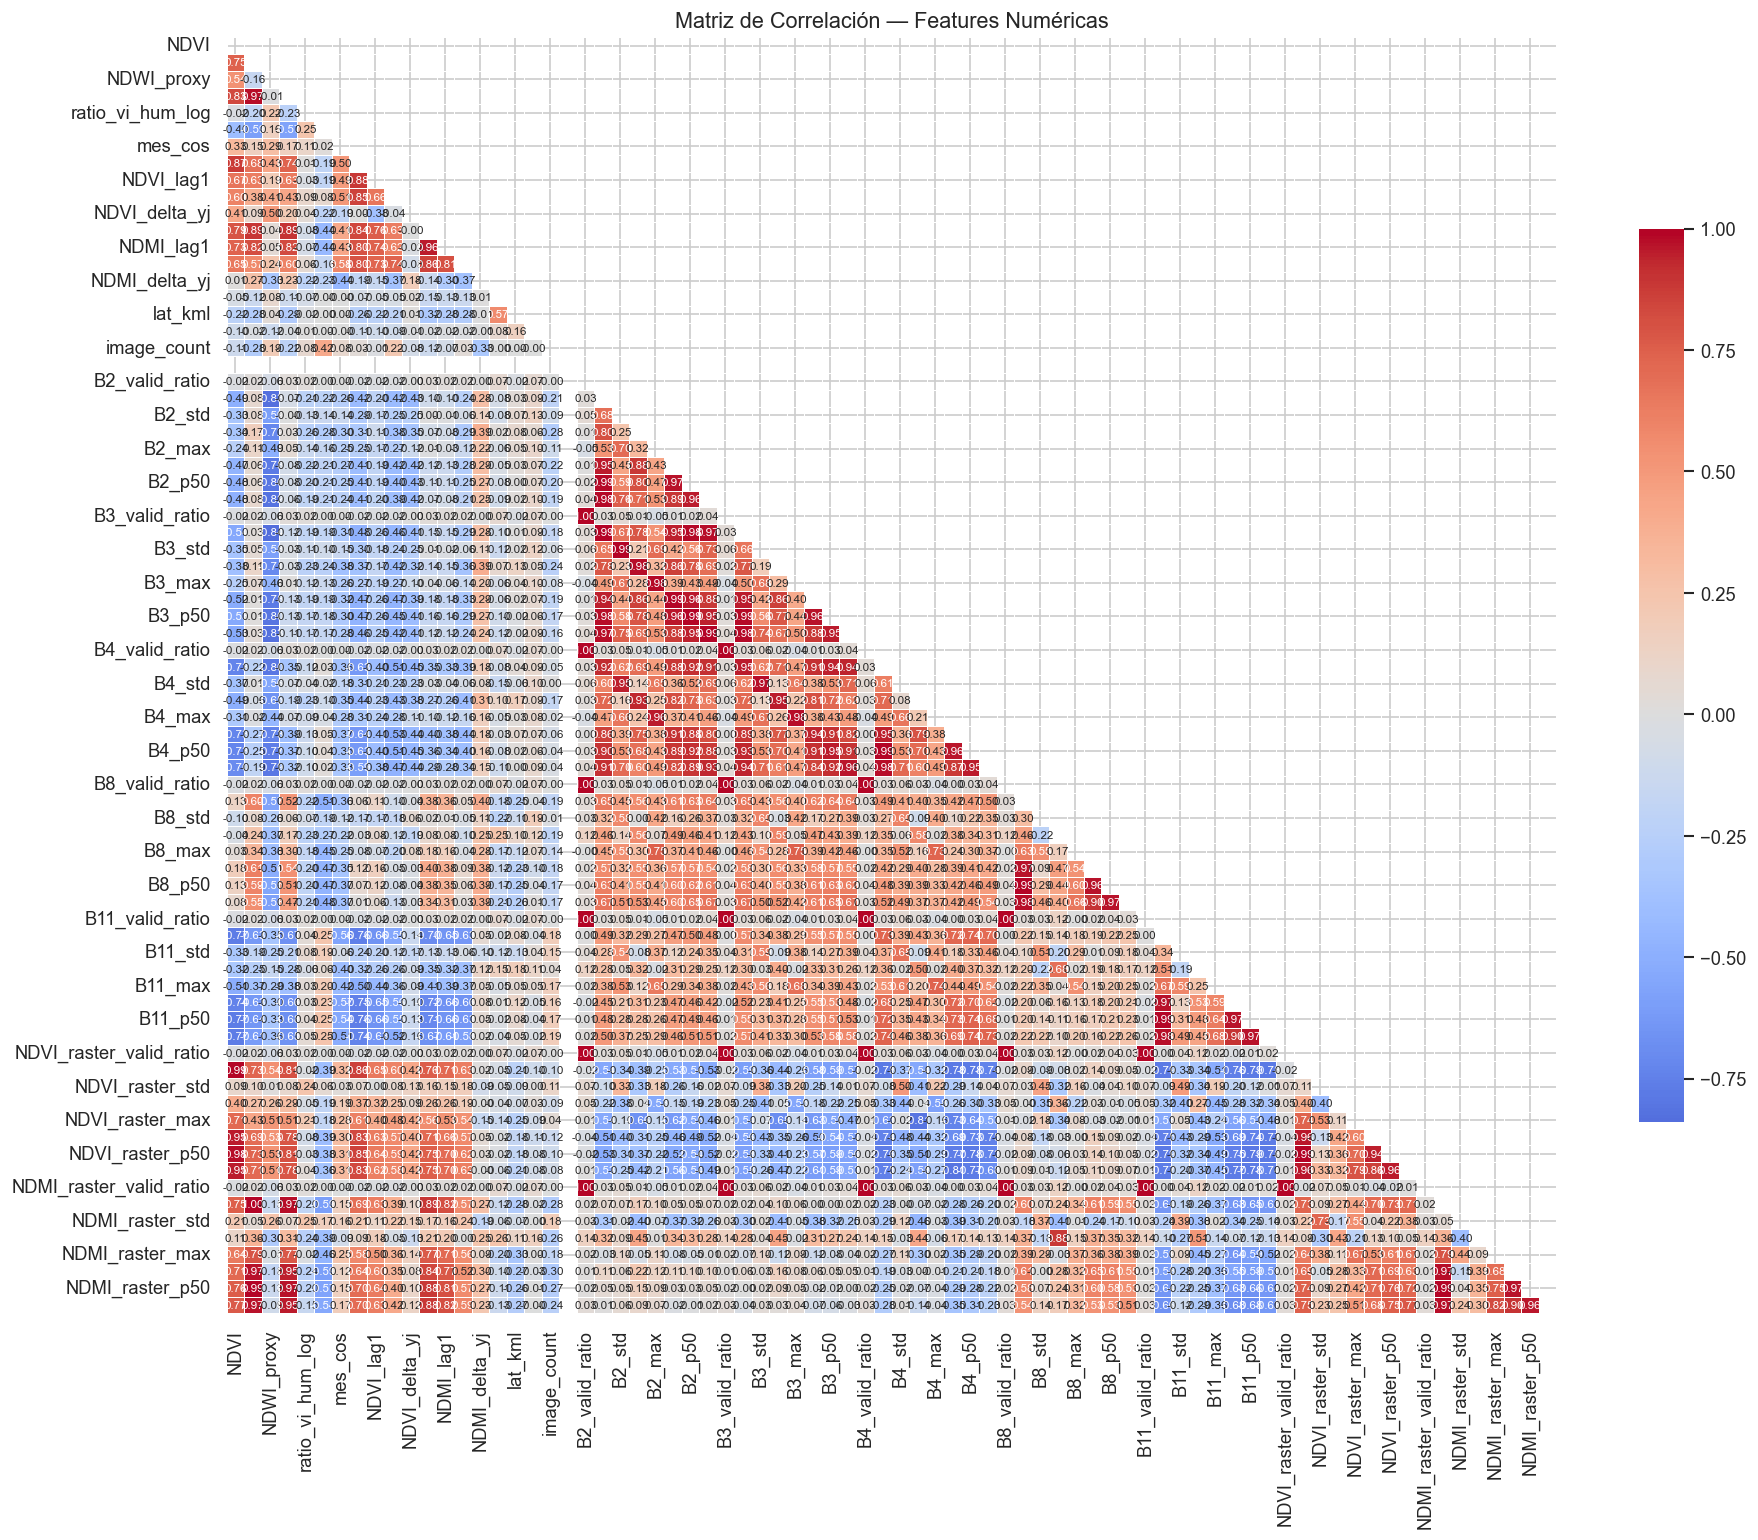

Pares con |r| > 0.9:
  B2_valid_ratio ↔ B3_valid_ratio: r=1.0
  B2_valid_ratio ↔ B4_valid_ratio: r=1.0
  B2_valid_ratio ↔ B8_valid_ratio: r=1.0
  B2_valid_ratio ↔ B11_valid_ratio: r=1.0
  B2_valid_ratio ↔ NDVI_raster_valid_ratio: r=1.0
  B2_valid_ratio ↔ NDMI_raster_valid_ratio: r=1.0
  B3_valid_ratio ↔ B4_valid_ratio: r=1.0
  B3_valid_ratio ↔ B8_valid_ratio: r=1.0
  B3_valid_ratio ↔ B11_valid_ratio: r=1.0
  B3_valid_ratio ↔ NDVI_raster_valid_ratio: r=1.0
  B3_valid_ratio ↔ NDMI_raster_valid_ratio: r=1.0
  B4_valid_ratio ↔ B8_valid_ratio: r=1.0
  B4_valid_ratio ↔ B11_valid_ratio: r=1.0
  B4_valid_ratio ↔ NDVI_raster_valid_ratio: r=1.0
  B4_valid_ratio ↔ NDMI_raster_valid_ratio: r=1.0
  B8_valid_ratio ↔ B11_valid_ratio: r=1.0
  B8_valid_ratio ↔ NDVI_raster_valid_ratio: r=1.0
  B8_valid_ratio ↔ NDMI_raster_valid_ratio: r=1.0
  B11_valid_ratio ↔ NDVI_raster_valid_ratio: r=1.0
  B11_valid_ratio ↔ NDMI_raster_valid_ratio: r=1.0
  NDVI_raster_valid_ratio ↔ NDMI_raster_valid_ratio: r=1.0
  ND

In [37]:
corr_matrix = fe_t[features_num_final].corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            cbar_kws={'shrink': 0.7}, ax=ax, annot_kws={'size': 7})
ax.set_title('Matriz de Correlación — Features Numéricas', fontsize=13)
plt.tight_layout()
plt.show()

# Identificar pares altamente correlacionados
umbral_corr = 0.90
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
pares_altos = [
    (c1, c2, round(upper.loc[c1, c2], 3))
    for c1 in upper.columns
    for c2 in upper.columns
    if pd.notna(upper.loc[c1, c2]) and abs(upper.loc[c1, c2]) > umbral_corr
]

if pares_altos:
    print(f'Pares con |r| > {umbral_corr}:')
    for c1, c2, r in sorted(pares_altos, key=lambda x: -abs(x[2])):
        print(f'  {c1} ↔ {c2}: r={r}')
else:
    print(f'No se detectaron pares con |r| > {umbral_corr}')

In [38]:
# Eliminar columnas redundantes detectadas
# Se conserva la versión más informativa o la original
cols_a_eliminar = []
umbral_drop = 0.90

upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
for col in upper_tri.columns:
    if any(abs(upper_tri[col]) > umbral_drop):
        # Conservar la primera de cada par; eliminar la segunda
        cols_a_eliminar.append(col)

# No eliminar NDVI ni NDMI originales: son las variables base del dominio
cols_a_eliminar = [c for c in cols_a_eliminar
                   if c not in ['NDVI', 'NDMI', 'NDVI_roll3', 'NDMI_roll3']]

features_post_corr = [c for c in features_num_final if c not in cols_a_eliminar]

print(f'Features eliminadas por alta correlación: {cols_a_eliminar}')
print(f'Features retenidas post correlación: {len(features_post_corr)}')
print(features_post_corr)

Features eliminadas por alta correlación: ['vegetacion_activa_yj', 'NDMI_lag1', 'B2_p25', 'B2_p50', 'B2_p75', 'B3_valid_ratio', 'B3_mean', 'B3_std', 'B3_min', 'B3_max', 'B3_p25', 'B3_p50', 'B3_p75', 'B4_valid_ratio', 'B4_mean', 'B4_std', 'B4_min', 'B4_max', 'B4_p25', 'B4_p50', 'B4_p75', 'B8_valid_ratio', 'B8_p25', 'B8_p50', 'B8_p75', 'B11_valid_ratio', 'B11_p25', 'B11_p50', 'B11_p75', 'NDVI_raster_valid_ratio', 'NDVI_raster_mean', 'NDVI_raster_p25', 'NDVI_raster_p50', 'NDVI_raster_p75', 'NDMI_raster_valid_ratio', 'NDMI_raster_mean', 'NDMI_raster_p25', 'NDMI_raster_p50', 'NDMI_raster_p75']
Features retenidas post correlación: 37
['NDVI', 'NDMI', 'NDWI_proxy', 'ratio_vi_hum_log', 'mes_sin', 'mes_cos', 'NDVI_roll3', 'NDVI_lag1', 'NDVI_lag2', 'NDVI_delta_yj', 'NDMI_roll3', 'NDMI_lag2', 'NDMI_delta_yj', 'lon_kml', 'lat_kml', 'dist_centroide_sqrt', 'image_count', 'raster_missing', 'B2_valid_ratio', 'B2_mean', 'B2_std', 'B2_min', 'B2_max', 'B8_mean', 'B8_std', 'B8_min', 'B8_max', 'B11_mean', 

### 5.3 ANOVA F-score (Selección Supervisada)

**Justificación:**  
El test ANOVA evalúa si la media de cada variable numérica difiere significativamente entre las 3 clases de estrés hídrico. Un F-score alto indica que la variable es discriminativa para la clasificación. Es un método de filtrado supervisado adecuado para el objetivo de clasificación multiclase del proyecto.

=== ANOVA F-score por característica ===


,F_score,p_value,Significativa (p<0.05)
Feature,,,
NDMI,3278.1473,0.0000,✓
NDMI_roll3,2664.0053,0.0000,✓
NDMI_raster_max,2201.7009,0.0000,✓
NDVI,1368.6956,0.0000,✓
NDVI_roll3,1077.4073,0.0000,✓
NDMI_lag2,874.7780,0.0000,✓
NDVI_lag1,801.5201,0.0000,✓
NDVI_raster_max,764.7085,0.0000,✓
B11_mean,733.4049,0.0000,✓


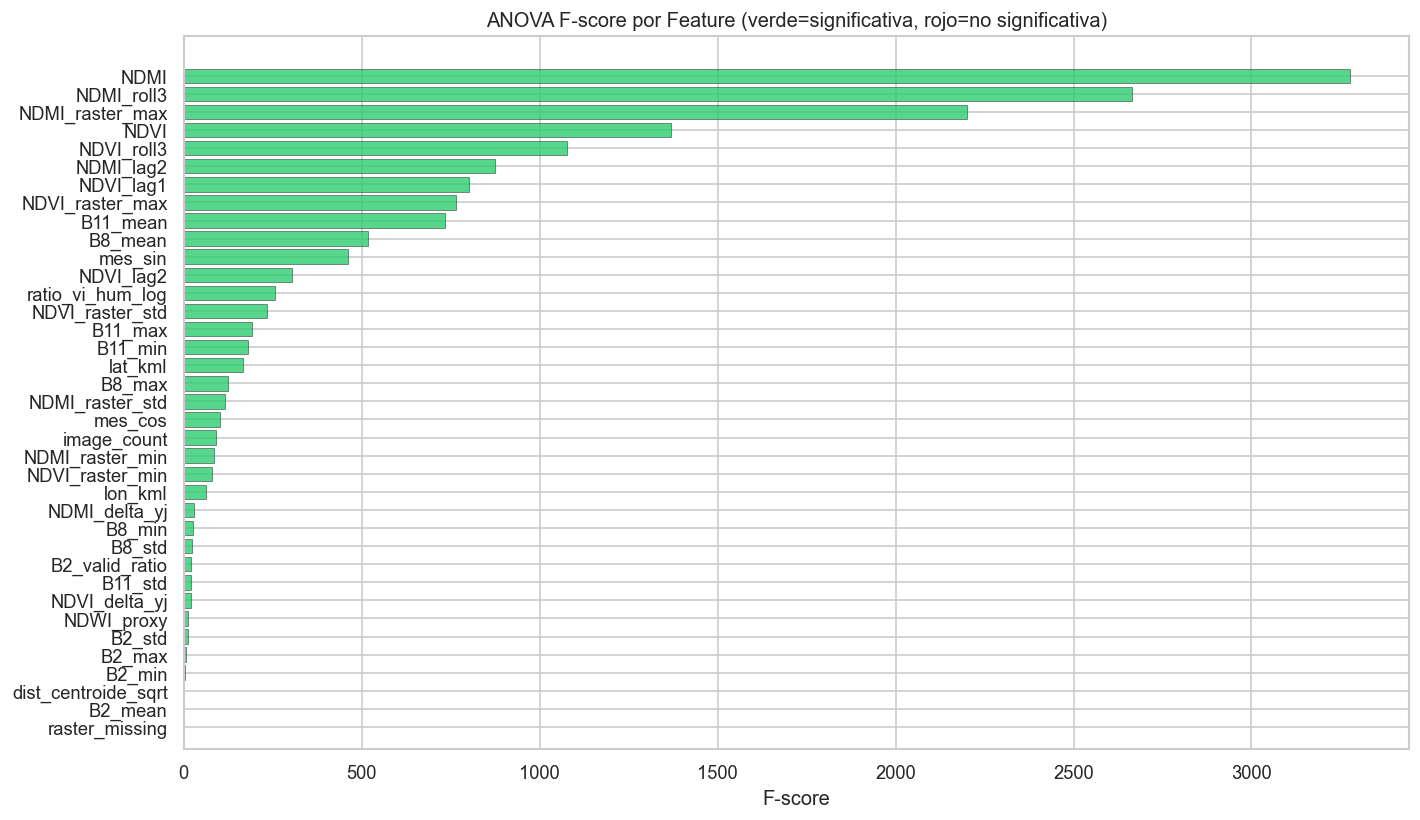


Features significativas (p<0.05): 34
['NDMI', 'NDMI_roll3', 'NDMI_raster_max', 'NDVI', 'NDVI_roll3', 'NDMI_lag2', 'NDVI_lag1', 'NDVI_raster_max', 'B11_mean', 'B8_mean', 'mes_sin', 'NDVI_lag2', 'ratio_vi_hum_log', 'NDVI_raster_std', 'B11_max', 'B11_min', 'lat_kml', 'B8_max', 'NDMI_raster_std', 'mes_cos', 'image_count', 'NDMI_raster_min', 'NDVI_raster_min', 'lon_kml', 'NDMI_delta_yj', 'B8_min', 'B8_std', 'B2_valid_ratio', 'B11_std', 'NDVI_delta_yj', 'NDWI_proxy', 'B2_std', 'B2_max', 'B2_min']


In [39]:
X_anova = fe_t[features_post_corr].copy()
y_anova = fe_t['stress_label']

selector_anova = SelectKBest(score_func=f_classif, k='all')
selector_anova.fit(X_anova, y_anova)

anova_results = pd.DataFrame({
    'Feature': features_post_corr,
    'F_score': selector_anova.scores_,
    'p_value': selector_anova.pvalues_
}).sort_values('F_score', ascending=False)

anova_results['Significativa (p<0.05)'] = anova_results['p_value'].apply(
    lambda p: '✓' if p < 0.05 else '✗'
)

print('=== ANOVA F-score por característica ===')
display(anova_results.set_index('Feature').round(4))

fig, ax = plt.subplots(figsize=(12, 7))
colors_anova = ['#2ecc71' if p < 0.05 else '#e74c3c'
                for p in anova_results['p_value']]
ax.barh(anova_results['Feature'], anova_results['F_score'],
        color=colors_anova, alpha=0.8, edgecolor='black', lw=0.3)
ax.set_title('ANOVA F-score por Feature (verde=significativa, rojo=no significativa)')
ax.set_xlabel('F-score')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# Features significativas
features_significativas = anova_results[
    anova_results['p_value'] < 0.05
]['Feature'].tolist()
print(f'\nFeatures significativas (p<0.05): {len(features_significativas)}')
print(features_significativas)

### 5.4 Chi-cuadrado (Variables Binarias/Discretas)

**Justificación:**  
El test Chi-cuadrado evalúa la dependencia estadística entre variables categóricas o binarias y la variable objetivo. Se aplica sobre `temporada_lluvias` y las columnas OHE de estación, ya que estas son variables discretas no negativas. Permite confirmar si la estacionalidad influye significativamente en la clase de estrés.

=== Chi-cuadrado — Variables Discretas ===


,Chi2_score,p_value,Significativa (p<0.05)
Feature,,,
estacion_primavera,457.2224,0.0,✓
estacion_otono,266.6615,0.0,✓
temporada_lluvias,37.3807,0.0,✓
estacion_verano,26.0274,0.0,✓


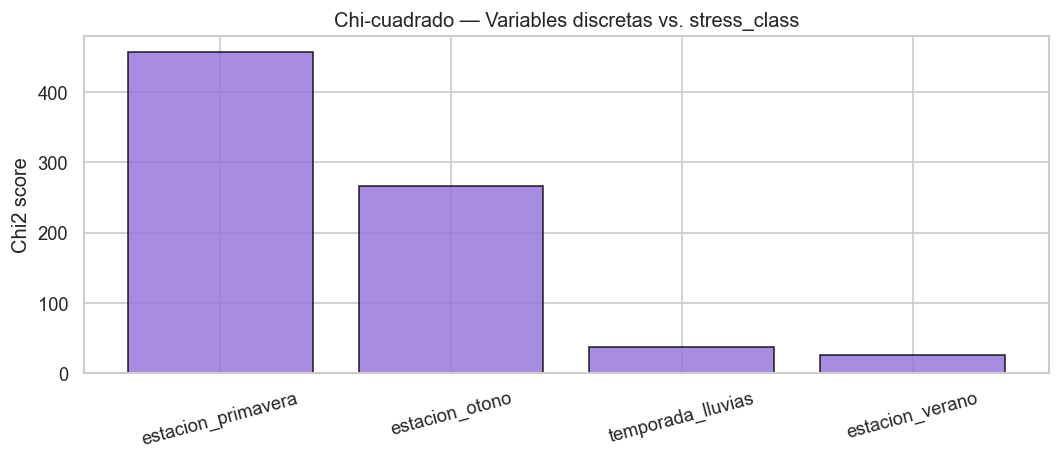

In [40]:
chi_cols = ['temporada_lluvias'] + estacion_cols
X_chi = fe_t[chi_cols].astype(int)
y_chi = fe_t['stress_label']

selector_chi = SelectKBest(score_func=chi2, k='all')
selector_chi.fit(X_chi, y_chi)

chi_results = pd.DataFrame({
    'Feature': chi_cols,
    'Chi2_score': selector_chi.scores_,
    'p_value': selector_chi.pvalues_
}).sort_values('Chi2_score', ascending=False)

chi_results['Significativa (p<0.05)'] = chi_results['p_value'].apply(
    lambda p: '✓' if p < 0.05 else '✗'
)

print('=== Chi-cuadrado — Variables Discretas ===')
display(chi_results.set_index('Feature').round(4))

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(chi_results['Feature'], chi_results['Chi2_score'],
       color='mediumpurple', alpha=0.8, edgecolor='black')
ax.set_title('Chi-cuadrado — Variables discretas vs. stress_class')
ax.set_ylabel('Chi2 score')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

---
## 6. Extracción de Características

### 6.1 Análisis de Componentes Principales (PCA)

**Justificación:**  
PCA reduce la dimensionalidad del espacio de características proyectando los datos sobre los ejes de máxima varianza. Sus beneficios en este proyecto:
1. **Reduce almacenamiento y complejidad del modelo** al comprimir ~19 features en ≤5 componentes.
2. **Elimina multicolinealidad residual**: los componentes son ortogonales por construcción.
3. **Acelera el entrenamiento** al reducir el espacio de búsqueda.
4. **Mejora la generalización** en datasets de tamaño moderado como el presente (4000 obs).

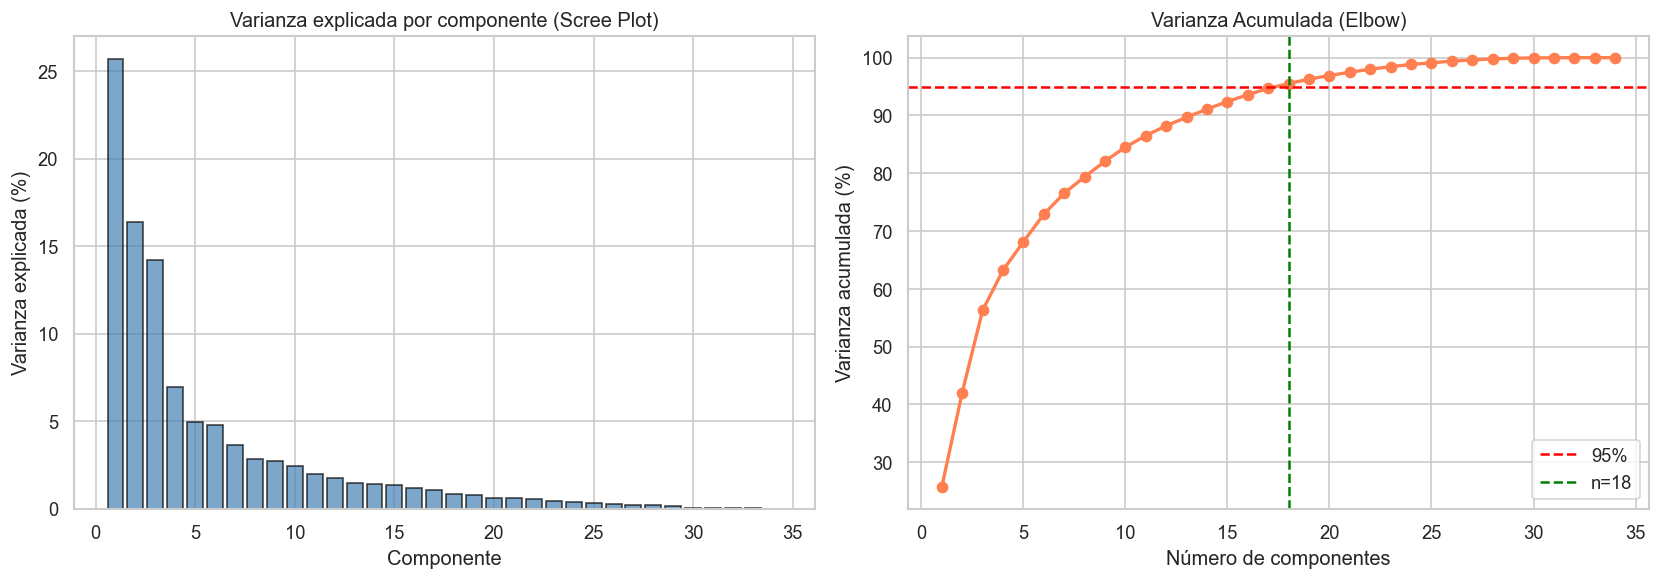

Componentes necesarios para explicar 95% de varianza: 18
Reducción dimensional: 34 → 18 componentes


In [41]:
# Usar las features significativas estandarizadas
X_pca = fe_t[[f'{c}_sc' for c in features_significativas
              if f'{c}_sc' in fe_t.columns]]

# Si alguna feature significativa no tiene versión _sc, usar la original
feats_pca_final = []
for f in features_significativas:
    sc = f'{f}_sc'
    if sc in fe_t.columns:
        feats_pca_final.append(sc)
    elif f in fe_t.columns:
        feats_pca_final.append(f)

X_pca = fe_t[feats_pca_final].fillna(0)

pca_full = PCA()
pca_full.fit(X_pca)

varianza_acum = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = np.argmax(varianza_acum >= 0.95) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Varianza explicada por componente
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_)+1),
            pca_full.explained_variance_ratio_ * 100,
            color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_title('Varianza explicada por componente (Scree Plot)')
axes[0].set_xlabel('Componente')
axes[0].set_ylabel('Varianza explicada (%)')

# Varianza acumulada
axes[1].plot(range(1, len(varianza_acum)+1), varianza_acum * 100,
             marker='o', color='coral', linewidth=2)
axes[1].axhline(95, color='red', linestyle='--', linewidth=1.5, label='95%')
axes[1].axvline(n_components_95, color='green', linestyle='--',
                linewidth=1.5, label=f'n={n_components_95}')
axes[1].set_title('Varianza Acumulada (Elbow)')
axes[1].set_xlabel('Número de componentes')
axes[1].set_ylabel('Varianza acumulada (%)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Componentes necesarios para explicar 95% de varianza: {n_components_95}')
print(f'Reducción dimensional: {X_pca.shape[1]} → {n_components_95} componentes')

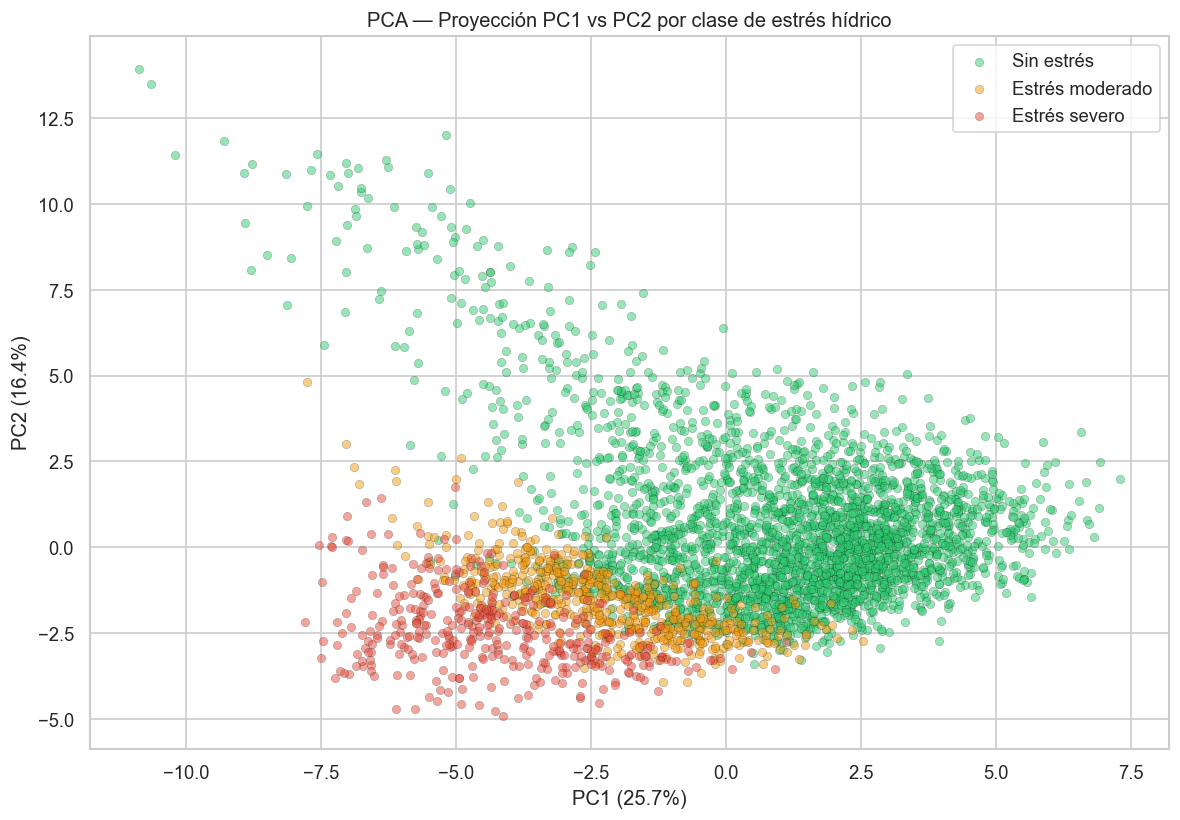

✓ PCA completado: 18 componentes, 95.5% varianza explicada


In [42]:
# Aplicar PCA con n_components_95
pca_final = PCA(n_components=n_components_95)
X_pca_reduced = pca_final.fit_transform(X_pca)

pca_df = pd.DataFrame(
    X_pca_reduced,
    columns=[f'PC{i+1}' for i in range(n_components_95)]
)
pca_df['stress_label'] = fe_t['stress_label'].values
pca_df['stress_class'] = fe_t['stress_class'].values

# Biplot PC1 vs PC2
fig, ax = plt.subplots(figsize=(10, 7))
colors_pca = {0: '#2ecc71', 1: '#f39c12', 2: '#e74c3c'}
labels_pca = {0: 'Sin estrés', 1: 'Estrés moderado', 2: 'Estrés severo'}

for label, grp in pca_df.groupby('stress_label'):
    ax.scatter(grp['PC1'], grp['PC2'],
               label=labels_pca[label],
               color=colors_pca[label],
               alpha=0.5, s=25, edgecolor='black', linewidth=0.2)

ax.set_xlabel(f'PC1 ({pca_final.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_final.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA — Proyección PC1 vs PC2 por clase de estrés hídrico')
ax.legend()
plt.tight_layout()
plt.show()

print(f'✓ PCA completado: {n_components_95} componentes, {varianza_acum[n_components_95-1]*100:.1f}% varianza explicada')

### 6.2 Análisis Factorial (FA)

**Justificación:**  
El Análisis Factorial busca variables latentes que explican la covarianza entre las características observadas. A diferencia de PCA (que maximiza varianza total), FA asume que las variables observadas son combinaciones de factores latentes más ruido. En el contexto agronómico, los factores latentes pueden corresponder a:
- **Factor 1:** Condición hídrica general (dominado por NDMI, lags NDMI)
- **Factor 2:** Vigor vegetativo (dominado por NDVI, NDVI_roll3)
- **Factor 3:** Dinámica temporal (deltas, lags tardíos)

Facilita la interpretación del espacio de características y su relación con la variable objetivo.

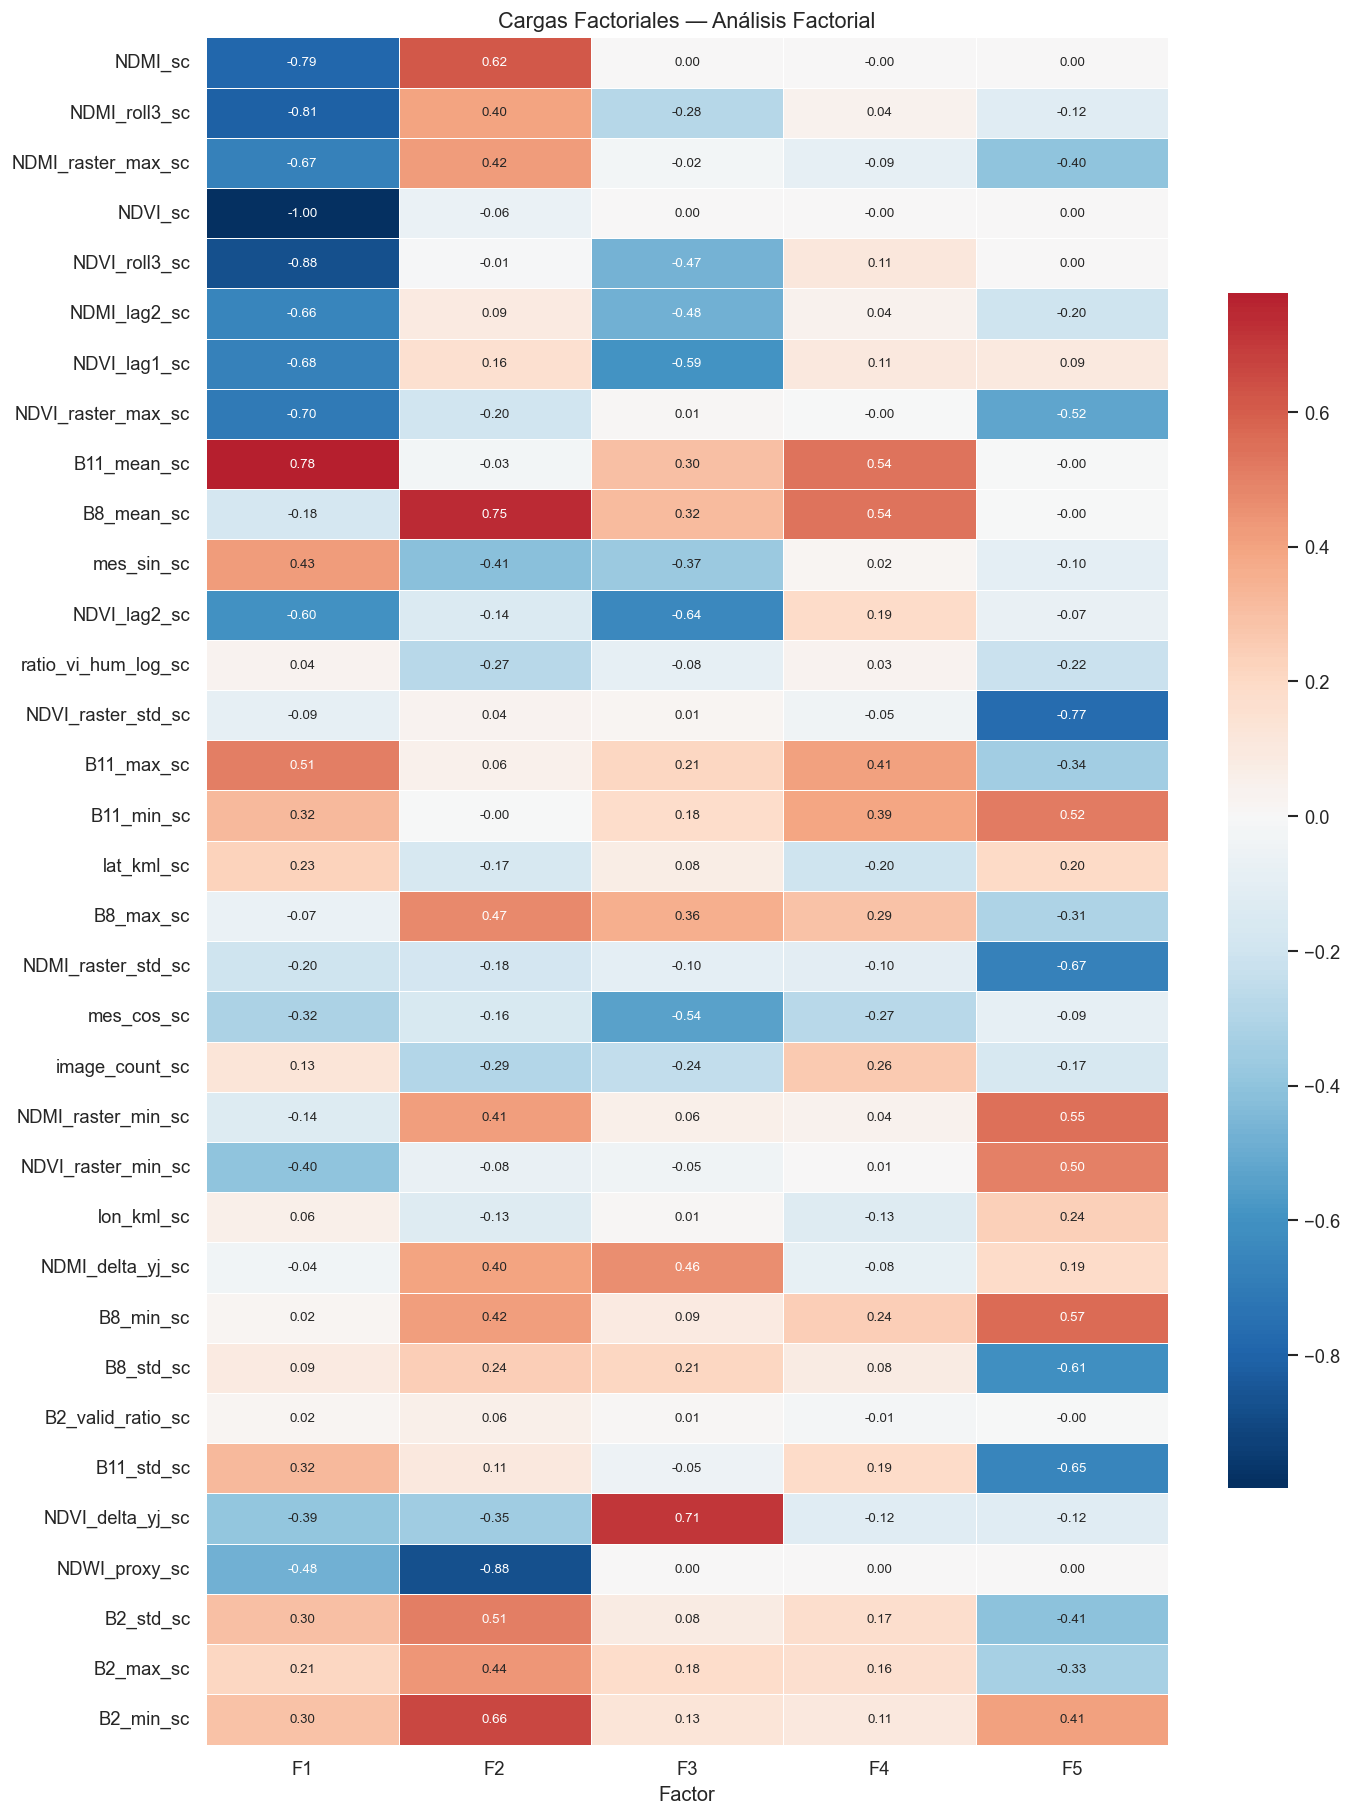

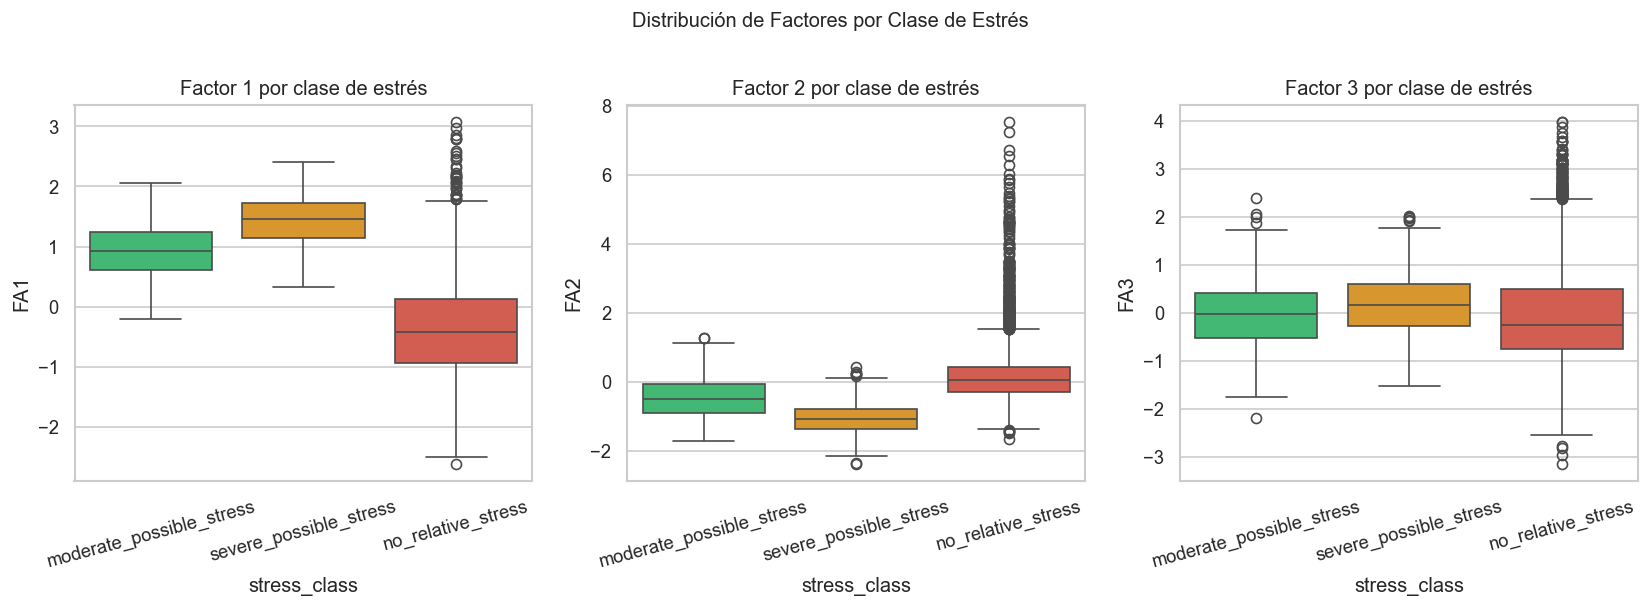

✓ Análisis Factorial completado: 5 factores extraídos


In [43]:
n_factors = min(5, X_pca.shape[1] - 1)

fa = FactorAnalysis(n_components=n_factors, random_state=42)
X_fa = fa.fit_transform(X_pca)

# Matriz de cargas factoriales
loadings = pd.DataFrame(
    fa.components_.T,
    index=feats_pca_final,
    columns=[f'F{i+1}' for i in range(n_factors)]
)

fig, ax = plt.subplots(figsize=(12, max(6, len(feats_pca_final) * 0.45)))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, cbar_kws={'shrink': 0.7},
            ax=ax, annot_kws={'size': 8})
ax.set_title('Cargas Factoriales — Análisis Factorial', fontsize=13)
ax.set_xlabel('Factor')
plt.tight_layout()
plt.show()

# DataFrame con los factores
fa_df = pd.DataFrame(X_fa, columns=[f'FA{i+1}' for i in range(n_factors)])
fa_df['stress_class'] = fe_t['stress_class'].values

# Boxplot de FA1 por clase
fig, axes = plt.subplots(1, min(3, n_factors), figsize=(14, 5))
if min(3, n_factors) == 1:
    axes = [axes]
for i in range(min(3, n_factors)):
    sns.boxplot(data=fa_df, x='stress_class', y=f'FA{i+1}',
                palette=['#2ecc71', '#f39c12', '#e74c3c'], ax=axes[i])
    axes[i].set_title(f'Factor {i+1} por clase de estrés')
    axes[i].tick_params(axis='x', rotation=15)
plt.suptitle('Distribución de Factores por Clase de Estrés', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

print(f'✓ Análisis Factorial completado: {n_factors} factores extraídos')

---
## 7. Construcción del Dataset Final

Se consolida el dataset final con las características seleccionadas y los componentes extraídos, listo para la fase de modelado.

In [44]:
# Dataset final: features originales significativas estandarizadas + PCA + FA + target
df_final = fe_t[['name', 'date', 'year', 'month', 'stress_class', 'stress_label']].copy()

# Añadir features estandarizadas significativas
for f in features_significativas:
    sc = f'{f}_sc'
    if sc in fe_t.columns:
        df_final[sc] = fe_t[sc].values
    elif f in fe_t.columns:
        df_final[f] = fe_t[f].values

# Añadir componentes PCA
for col in [f'PC{i+1}' for i in range(n_components_95)]:
    df_final[col] = pca_df[col].values

# Añadir factores FA
for col in [f'FA{i+1}' for i in range(n_factors)]:
    df_final[col] = fa_df[col].values

print(f'Dataset final: {df_final.shape}')
print(f'Columnas: {list(df_final.columns)}')
display(df_final.head())

# Guardar
output_path = 'df_fe_avance2.csv'
df_final.to_csv(output_path, index=False)
print(f'\n✓ Dataset guardado: {output_path}')
print(f'  Dimensiones: {df_final.shape[0]} obs × {df_final.shape[1]} columnas')

Dataset final: (4000, 63)
Columnas: ['name', 'date', 'year', 'month', 'stress_class', 'stress_label', 'NDMI_sc', 'NDMI_roll3_sc', 'NDMI_raster_max_sc', 'NDVI_sc', 'NDVI_roll3_sc', 'NDMI_lag2_sc', 'NDVI_lag1_sc', 'NDVI_raster_max_sc', 'B11_mean_sc', 'B8_mean_sc', 'mes_sin_sc', 'NDVI_lag2_sc', 'ratio_vi_hum_log_sc', 'NDVI_raster_std_sc', 'B11_max_sc', 'B11_min_sc', 'lat_kml_sc', 'B8_max_sc', 'NDMI_raster_std_sc', 'mes_cos_sc', 'image_count_sc', 'NDMI_raster_min_sc', 'NDVI_raster_min_sc', 'lon_kml_sc', 'NDMI_delta_yj_sc', 'B8_min_sc', 'B8_std_sc', 'B2_valid_ratio_sc', 'B11_std_sc', 'NDVI_delta_yj_sc', 'NDWI_proxy_sc', 'B2_std_sc', 'B2_max_sc', 'B2_min_sc', 'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11', 'PC12', 'PC13', 'PC14', 'PC15', 'PC16', 'PC17', 'PC18', 'FA1', 'FA2', 'FA3', 'FA4', 'FA5']


,name,date,year,month,stress_class,stress_label,NDMI_sc,NDMI_roll3_sc,NDMI_raster_max_sc,NDVI_sc,...,PC14,PC15,PC16,PC17,PC18,FA1,FA2,FA3,FA4,FA5
0,H1,2023-01-01,2023,1,moderate_possible_stress,1,-1.022531,-1.132622,0.156160,-1.366467,...,0.097574,-0.792891,0.678830,-0.177915,-0.135962,1.363864,0.084364,0.157333,-1.950609,-1.538202
1,H1,2023-02-01,2023,2,severe_possible_stress,2,-1.393120,-1.335875,-0.713439,-1.940279,...,0.427579,-1.025476,0.938050,-0.278326,-0.885300,1.930918,0.208010,-0.141508,-1.803538,-1.095780
2,H1,2023-03-01,2023,3,severe_possible_stress,2,-1.660000,-1.501208,-0.743550,-2.095917,...,0.513019,-1.177690,0.834673,-0.524522,-1.055979,2.100751,-0.008067,0.096265,-1.579355,-0.857489
3,H1,2023-04-01,2023,4,severe_possible_stress,2,-1.676947,-1.740489,-0.789239,-2.269056,...,0.322247,-0.876757,0.476886,-0.897147,-1.163643,2.262711,0.171589,0.581382,-1.298962,-0.811853
4,H1,2023-05-01,2023,5,severe_possible_stress,2,-1.783765,-1.883325,-0.485297,-2.250137,...,0.124856,-0.822966,0.275873,-1.042999,-1.258477,2.255483,-0.011091,0.901705,-1.116866,-0.992226



✓ Dataset guardado: df_fe_avance2.csv
  Dimensiones: 4000 obs × 63 columnas


---
## 8. Conclusiones — Fase de Preparación de Datos (CRISP-ML)

En el marco de la metodología **CRISP-ML(Q)** (*Cross-Industry Standard Process for Machine Learning with Quality Assurance*), la fase de **Preparación de los Datos** comprende las actividades de selección, limpieza, construcción y formateo de los datos. Los Avances 1 y 2 de este proyecto integrador cubren íntegramente esta fase:

---

### Avance 1 (EDA) — Selección y Limpieza

Se realizó una exploración exhaustiva de 100 parcelas aguacateras de Jalisco (4 000 observaciones mensuales, 2023–2026). Se identificaron y validaron los rangos físicos de NDVI y NDMI (ambos en [−1, 1]), confirmando un dataset limpio sin valores faltantes. Los análisis univariante, bivariante y temporal permitieron detectar la **estacionalidad del estrés hídrico** (máximo en temporada seca: febrero–mayo) y la correlación moderada-alta entre NDVI y NDMI (r=0.747), base para el diseño de features derivadas.

---

### Avance 2 (FE) — Construcción y Formateo

**A. Construcción de características:**  
Se generaron 18 nuevas características organizadas en cuatro grupos: (1) espectrales derivadas (`NDWI_proxy`, `vegetacion_activa`, `ratio_vi_hum`), que capturan el desbalance vigor-humedad; (2) temporales cíclicas (codificación sin/cos del mes, estación, `temporada_lluvias`), que eliminan el sesgo de distancia artificial en variables periódicas; (3) lags y medias móviles, que incorporan la memoria temporal del estrés hídrico; y (4) geoespaciales (`dist_centroide`), que aportan contexto de microclima.

**B. Codificación:**  
Se aplicó *One-Hot Encoding* a la variable `estacion` (sin orden intrínseco) y *Label Encoding ordinal explícito* a `stress_class`, preservando la jerarquía semántica de la variable objetivo.

**C. Transformaciones y escalamiento:**  
Las distribuciones sesgadas fueron corregidas mediante transformaciones logarítmicas, raíz cuadrada y Yeo-Johnson. La estandarización Z-score garantiza que todas las variables contribuyan equitativamente al gradiente durante el entrenamiento, acelerando la convergencia en algoritmos sensibles a escala (SVM, regresión logística, redes neuronales).

**D. Selección de características:**  
El filtro de umbral de varianza eliminó características cuasi-constantes. El análisis de correlación redujo la multicolinealidad entre features redundantes. El test ANOVA (F-score) identificó las variables numéricas con mayor poder discriminativo entre clases de estrés, y el Chi-cuadrado confirmó la influencia estadísticamente significativa de la estacionalidad sobre la variable objetivo.

**E. Extracción:**  
PCA comprimió el espacio de features en un número reducido de componentes que explican el 95% de la varianza, eliminando multicolinealidad residual y reduciendo el tiempo de entrenamiento. El Análisis Factorial reveló la estructura latente del dataset: los factores identificados se alinean con las dimensiones de condición hídrica, vigor vegetativo y dinámica temporal, facilitando la interpretación de los resultados del modelo.

---

**Evaluación de calidad (CRISP-ML Quality Gates):**  
✅ Dataset sin valores faltantes tras relleno de lags por media de parcela.  
✅ Variables escaladas y transformadas para garantizar impacto equitativo en el modelo.  
✅ Dimensionalidad reducida de >19 features a un subconjunto de componentes PCA/FA ortogonales.  
✅ Variable objetivo codificada con orden semántico correcto.  
✅ Trazabilidad completa: cada decisión de procesamiento está documentada y justificada.  

El dataset resultante (`df_fe_avance2.csv`) está listo para la fase de **Modelado** de CRISP-ML, donde se entrenará, evaluará y seleccionará el mejor modelo predictivo de estrés hídrico.

---

### Incorporación adicional de imágenes Sentinel‑2

Como complemento al Feature Engineering tabular, se integraron características derivadas de patches GeoTIFF multibanda. Esta adición permite que el dataset final no solo represente promedios mensuales de NDVI/NDMI, sino también patrones espaciales resumidos dentro de cada parcela. En términos de CRISP‑ML, esta decisión fortalece la preparación de datos al enriquecer la representación de entrada sin incrementar de forma excesiva la dimensionalidad ni comprometer la trazabilidad del pipeline. Estas nuevas variables resumen la distribución espacial de bandas e índices dentro de cada parcela, incluyendo medias, máximos, mínimos, desviaciones estándar y proporción de píxeles válidos. Por ello, el nuevo dataset aumenta a 63 columnas, sin cambiar el número de observaciones. Esta ampliación permite capturar heterogeneidad interna de las parcelas que no era visible en los promedios mensuales originales.
